# Clustering and Initialization

## K - means implementation
These cells contain an implementation of k-means and k-means++ algorithm 

In [29]:
import numpy as np
import warnings

def kmeans(k: int, points: np.ndarray, initial_centroids=None, max_iter=300, seed=42) -> tuple[np.ndarray, np.ndarray]:
    """
    Implements k-means algorithm for clustering.

    Parameters
    ----------
    k: int
        Number of clusters
    points: numpy.ndarray
        Dataset points
    initial_centroids: None , numpy.ndarray, optional
        The array of initial centroids, if None centroids will be randomly selected from points
    max_iter : int, optional
        Maximum number of iterations
    seed : int, optional
        Set the seed for random choices, default is 42

    Returns
    -------
    (numpy.ndarray, numpy.ndarray)
        mask of clusters for point and centroids
    """
    n, _ = points.shape
    np.random.seed(seed)
    # selecting initial centroids as random point in 'points' if None where passed as optional paramenter
    if initial_centroids is not None:
        centroids = np.array(initial_centroids, dtype=float)
    else:
        centroids = points[np.random.choice(n, k, replace=False)].copy()

    for _ in range(max_iter):
        xx = np.sum(points ** 2, axis=1)[:, None]
        cc = np.sum(centroids ** 2, axis=1)[None, :]
        distances = np.maximum(xx - 2 * points @ centroids.T + cc, 0) # expanded square of difference
        labels= np.argmin(distances, axis=1)

        new_centroids = np.empty_like(centroids)
        for i in range(k):
            mask = labels == i
            if mask.any(): 
                new_centroids[i] = points[mask].mean(axis=0)
            else: # empty
                min_dists = distances.min(axis=1)
                new_centroids[i] = points[np.argmax(min_dists)]
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    else:
        # recomputing the labels in case of exceeding iterations
        xx = np.sum(points ** 2, axis=1)[:, None]
        cc = np.sum(centroids ** 2, axis=1)[None, :]
        distances = np.maximum(xx - 2 * points @ centroids.T + cc, 0) # expanded square of difference
        labels= np.argmin(distances, axis=1)
        # generating a warning in case the algorithm does not converge
        warnings.warn(f'kmeans did not converge in {max_iter} iterations.')
    return labels, centroids


In [30]:
def kmeanspp(k: int, points: np.ndarray, max_iter=300, seed=42) -> tuple[np.ndarray, np.ndarray]:
    """
    Implements k-means++ algorithm for clustering.

    Parameters
    ----------
    k: int
        Number of clusters
    points: numpy.ndarray
        Dataset points
    max_iter : int, optional
        Maximum number of iterations
    seed : int, optional
        Set the seed for random choices, default is 42

    Returns
    -------
    (numpy.ndarray, numpy.ndarray)
        mask of clusters for point and centroids
    """
    np.random.seed(seed=seed)
    n = len(points)
    first_idx = np.random.randint(n)
    centroids = [points[first_idx]]

    while len(centroids) < k:
        c = np.array(centroids)
        xx = np.sum(points ** 2, axis=1)[:, None]
        cc = np.sum(c ** 2, axis=1)[None, :]
        distances = np.maximum(xx - 2 * points @ c.T + cc, 0)

        min_distances_sq = distances.min(axis=1)

        probabilities = min_distances_sq / min_distances_sq.sum()
        next_idx = np.random.choice(n, p=probabilities)
        centroids.append(points[next_idx])
    return kmeans(k, points, centroids, max_iter=max_iter, seed=seed)

## Synthetic dataset creation
These cells contain a function to generate a synthetic dataset similar to the one described in the paper, and some plots to better visualize the problem.

In [31]:
# synthetic dataset
def synthetic_dataset(n_centers: int, n_samples: int, n_features: int, sigma=1, hypercube_side=500, seed=42) -> tuple[list[np.ndarray], np.ndarray]:
    """
    Generates a synthetic dataset for clustering with 'n_centers' real centers.

    Each cluster is generated by sampling points from a multivariate normal distribution
    centered on a randomly placed point within a hypercube. The cluster centers are
    drawn uniformly at random in [0, hypercube_side]^n_features.

    Parameters
    ----------
    n_centers : int
        Number of clusters to generate.
    n_samples : int
        Number of points per cluster.
    n_features : int
        Dimensionality of each data point.
    sigma : float, optional
        Standard deviation of the normal distribution used to generate points
        around each center. Controls cluster spread. Default is 1.
    hypercube_side : float, optional
        Side length of the hypercube in which cluster centers are placed.
        Default is 500.
    seed : int, optional
        Random seed for reproducibility. Default is 42.

    Returns
    -------
    clusters : list of np.ndarray
        List of length `n_centers`, where each element is an array of shape
        (n_samples, n_features) containing the points belonging to that cluster.
    points : np.ndarray
        Array of shape (n_centers * n_samples, n_features) containing all
        generated points flattened into a single dataset.
    """
    np.random.seed(seed)
    centers = np.random.uniform(low=0, high=hypercube_side, size=(n_centers, n_features))

    clusters = []
    for center in centers:
        cluster = sigma * np.random.normal(size=(n_samples, n_features)) + center # 100 point per cluster
        clusters.append(cluster)

    # flatten all the clusters
    points = np.array([item for cluster in clusters for item in cluster])

    return clusters, points


Visualization of a simple 2D synthetic dataset with 25 true center and 100 points per center.

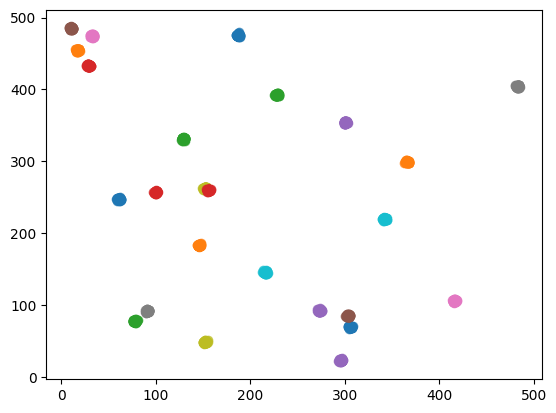

In [32]:
# plot clusters
import matplotlib.pyplot as plt

clusters, points = synthetic_dataset(25, 100, 2)
for cluster in clusters:
    cluster = np.array(cluster)
    plt.scatter(cluster[:, 0], cluster[:, 1], alpha=0.7)

plt.show()

Plot of the clusters found by k-mean algorithm

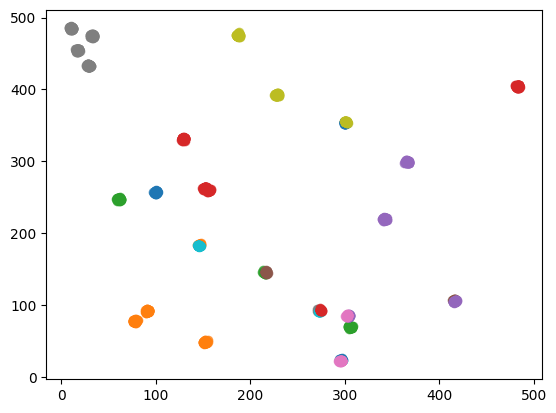

In [33]:
k = 25

labels, centroids = kmeans(k, points=points)

clusters = [points[labels == i] for i in range(k)]

for cluster in clusters:
    cluster = np.array(cluster)
    plt.scatter(cluster[:, 0], cluster[:, 1], alpha=0.7)

plt.show()

### A visual comparison of k-means and k-means++ algorithms
The first cell creates a simple 2D synthetic database for clustering by arbirarly choosing 5 true centers. Then it creates the associated points by sampling from a Gaussian distribution with mu = center and standard deviation = 1.

Then both k-means and k-means++ are run on the data and the obtained clusters are plotted.
Using the sliders it is possible to see how the clustering results vary in different random settings. It can be seen that k-means finds suboptimal solution more often than k-means++

In [34]:
np.random.seed(42)
centers_true = np.array([[0,0], [10,0], [5,8], [-5,8], [5,-8]])
points_per_cluster = 200
std = 1.0
X = np.vstack([np.random.randn(points_per_cluster, 2) * std + c 
               for c in centers_true])

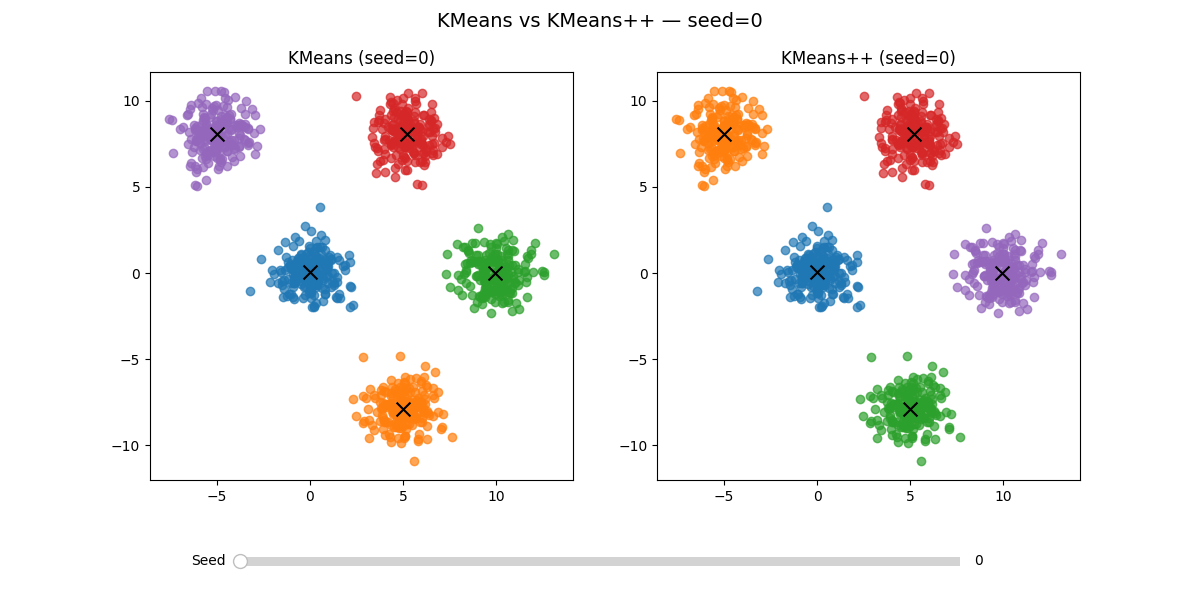

In [35]:
%matplotlib widget
# WARNING: run this cell again if not working.
#
# If widget does not work it can be replaced by 'qt' (requires PySide6)
# if the cell does not work it can be skipped or deleted, it is just for problem visualization
# it does not contain any experiment or any informative result 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

k = 5

widget_fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(bottom=0.2)

ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
slider = Slider(ax_slider, 'Seed', 0, 49, valinit=0, valstep=1)

def update(val):
    seed = int(slider.val)
    ax1.clear()
    ax2.clear()

    labels1, centroids1 = kmeans(k, X, seed=seed)
    for i in range(k):
        mask = labels1 == i
        ax1.scatter(X[mask, 0], X[mask, 1], alpha=0.7)
    ax1.scatter(centroids1[:, 0], centroids1[:, 1], c='black', marker='x', s=100)
    ax1.set_title(f"KMeans (seed={seed})")

    labels2, centroids2 = kmeanspp(k, X, seed=seed)
    for i in range(k):
        mask = labels2 == i
        ax2.scatter(X[mask, 0], X[mask, 1], alpha=0.7)
    ax2.scatter(centroids2[:, 0], centroids2[:, 1], c='black', marker='x', s=100)
    ax2.set_title(f"KMeans++ (seed={seed})")

    widget_fig.suptitle(f"KMeans vs KMeans++ — seed={seed}", fontsize=14)
    widget_fig.canvas.draw_idle()

slider.on_changed(update)

update(0)

plt.show()

## Running trials
In these cells several trials of k-means and k-means++ are run on different databases, for different values of $k$ and their inertia and varaibility are compared.

In [36]:
def plot_inertia_histograms(inertias_km, inertias_kmpp, bins=10):
    """
    1. Overlapped histograms of inertia distributions.
    Since the scales can be very different, we use two separate subplots.
    """
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 7))

    # k-means histogram
    ax0.hist(inertias_km, bins=bins, color="steelblue", edgecolor="white", alpha=0.85)
    ax0.axvline(np.mean(inertias_km), color="red", linestyle="--", label=f"Mean: {np.mean(inertias_km):.1f}")
    ax0.axvline(np.median(inertias_km), color="orange", linestyle="--", label=f"Median: {np.median(inertias_km):.1f}")
    ax0.set_title("k-means: Inertia Distribution")
    ax0.set_xlabel("Inertia")
    ax0.set_ylabel("Frequency")
    ax0.legend()

    # k-means++ histogram
    ax1.hist(inertias_kmpp, bins=bins, color="seagreen", edgecolor="white", alpha=0.85)
    ax1.axvline(np.mean(inertias_kmpp), color="red", linestyle="--", label=f"Mean: {np.mean(inertias_kmpp):.1f}")
    ax1.axvline(np.median(inertias_kmpp), color="orange", linestyle="--", label=f"Median: {np.median(inertias_kmpp):.1f}")
    ax1.set_title("k-means++: Inertia Distribution")
    ax1.set_xlabel("Inertia")
    ax1.set_ylabel("Frequency")
    ax1.legend()

    fig.suptitle("Distribution of Clustering Outcomes", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("1_inertia_histograms.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_inertia_boxplots(inertias_km, inertias_kmpp):
    _, ax = plt.subplots(figsize=(8, 6))

    bp = ax.boxplot(
        [inertias_km, inertias_kmpp],
        tick_labels=["k-means", "k-means++"],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="red", linewidth=2),
    )

    colors = ["steelblue", "seagreen"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_yscale("log")
    ax.set_ylabel("Inertia (log scale)")
    ax.set_title("Stability Comparison: Inertia Across Trials")

    for i, data in enumerate([inertias_km, inertias_kmpp]):
        stats = f"μ={np.mean(data):.1f}\nσ={np.std(data):.1f}\nCV={np.std(data)/np.mean(data):.3f}"
        ax.text(i + 1.3, np.median(data), stats, fontsize=8, va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    plt.tight_layout()
    plt.show()


In [37]:
import pandas as pd

def run_trials(k, n_trials, points):
    kmeans_inertia = np.empty(n_trials)
    kmeanspp_inertia = np.empty(n_trials)

    for i in range(n_trials):
        labels_km, centroids_kmeans = kmeans(k, points=points, seed=i)
        labels_kmpp, centroids_kmeanspp = kmeanspp(k, points=points, seed=i)

        inertia_kmeans = np.sum((points - centroids_kmeans[labels_km]) ** 2)
        inertia_kmeanspp = np.sum((points - centroids_kmeanspp[labels_kmpp]) ** 2)

        kmeans_inertia[i] = inertia_kmeans
        kmeanspp_inertia[i] = inertia_kmeanspp

    return kmeans_inertia, kmeanspp_inertia

def print_results(array: np.ndarray, name: str):
    mean = np.mean(array)
    std = np.std(array)
    min = np.min(array)
    max = np.max(array)
    median = np.median(array)

    cv = std / mean
    print(f'{name} Inertia - Mean: {mean:.2f}, Std: {std:.2f}, Min: {min:.2f}, Max: {max:.2f}, Median: {median:.2f}')
    print(f'{name} Variability: {cv}')

def get_indexes(inertia):
    mean = np.mean(inertia)
    std = np.std(inertia)
    min = np.min(inertia)
    max = np.max(inertia)
    median = np.median(inertia)
    cv = std / mean

    return mean, std, min, max, median, cv

def get_results(kmeans_inertia, kmeanspp_inertia, k):
    km_mean, km_std, km_min, km_max, km_median, km_cv = get_indexes(kmeans_inertia)
    kmpp_mean, kmpp_std, kmpp_min, kmpp_max, kmpp_median, kmpp_cv = get_indexes(kmeanspp_inertia)
    df = pd.DataFrame({
        'k-means': [
            f'{km_mean: .2f}',
            f'{km_std:.2f}',
            f'{km_min: .2f}',
            f'{km_max: .2f}',
            f'{km_median: .2f}',
            f'{km_cv: .2f}',
        ],
        'k-means++': [
            f'{kmpp_mean: .2f}',
            f'{kmpp_std:.2f}',
            f'{kmpp_min: .2f}',
            f'{kmpp_max: .2f}',
            f'{kmpp_median: .2f}',
            f'{kmpp_cv: .2f}',
        ],
    }, index=['Mean Inertia', 'Std Inertia', 'Min Inertia', 'Max Inertia', 'Median Inertia', 'CV Inertia'])

    return df

def run_trials_and_print_results(n_trials, k, points, dataset_name, save_tex=False):
    kmeans_inertia, kmeanspp_inertia = run_trials(k, n_trials, points)
    plot_inertia_histograms(kmeans_inertia, kmeanspp_inertia)
    plot_inertia_boxplots(kmeans_inertia, kmeanspp_inertia)
    
    df = get_results(kmeans_inertia, kmeanspp_inertia, k)
    display(df)

    # print percentage improvement 
    kmeans_inertia_mean = float(df.loc['Mean Inertia', 'k-means'])
    kppmeans_inertia_mean = float(df.loc['Mean Inertia', 'k-means++'])

    print(f'Percentage improvement: {100 * (1 - (kppmeans_inertia_mean / kmeans_inertia_mean)):.2f}%')
    if save_tex:
        # print latex table to file 
        with open(f'{dataset_name}_k_{k}.txt', 'w') as f:
            print(df.to_latex(), file=f)

    plt.close('all')  

In [38]:
N_TRIALS = 50
TEX= False # Change this to save LaTeX tables to file
ks =  [10, 25, 50] # The values of k for k-means (taken from the paper)

#### Synthetic dataset

Results for k = 10:


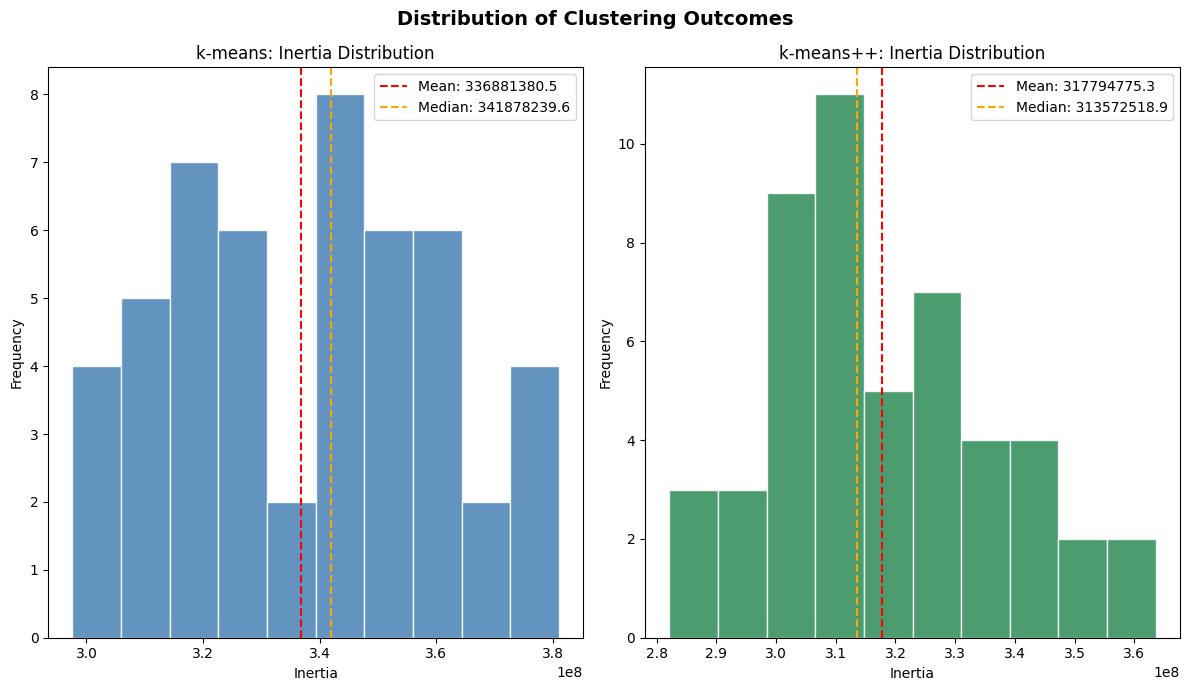

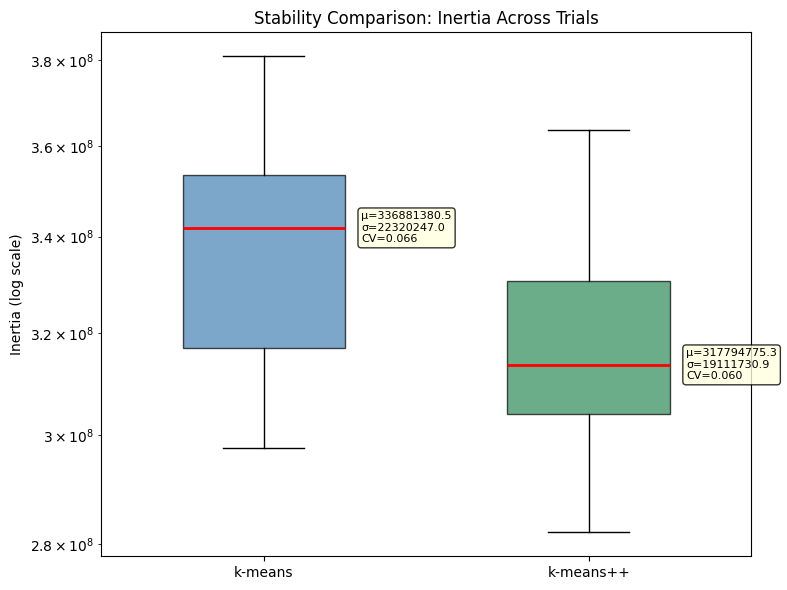

,k-means,k-means++
Mean Inertia,336881380.53,317794775.30
Std Inertia,22320246.96,19111730.92
Min Inertia,297607027.47,282112143.76
Max Inertia,381005009.72,363594185.12
Median Inertia,341878239.63,313572518.94
CV Inertia,0.07,0.06


Percentage improvement: 5.67%

Results for k = 25:


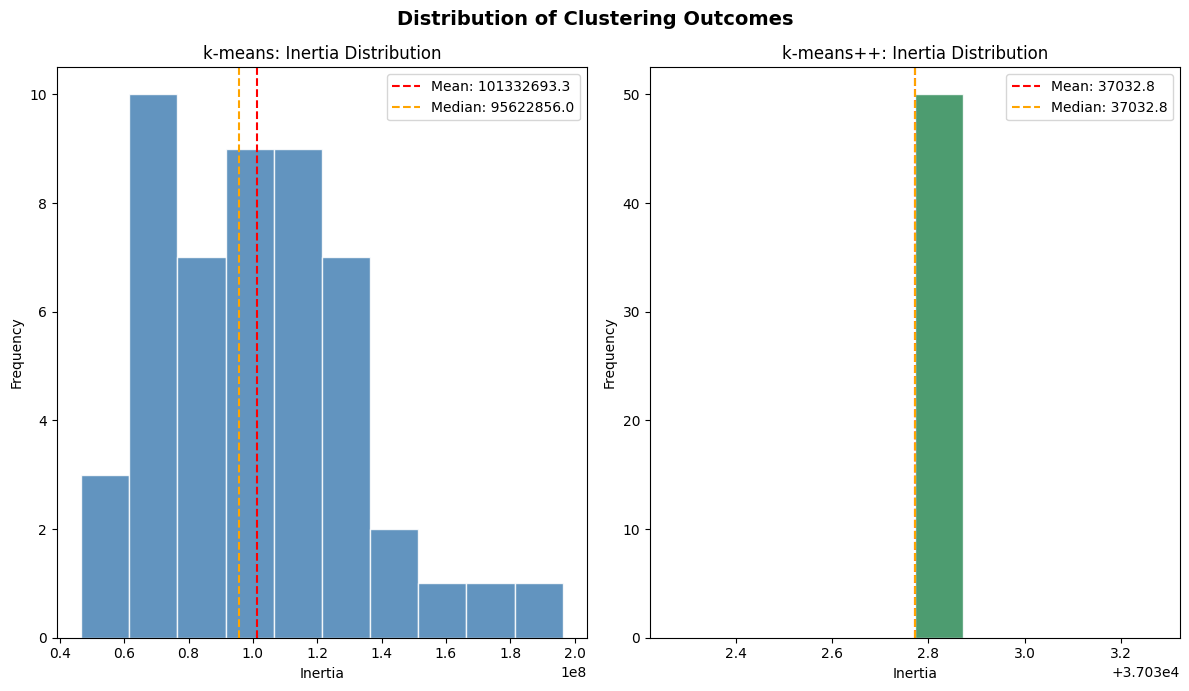

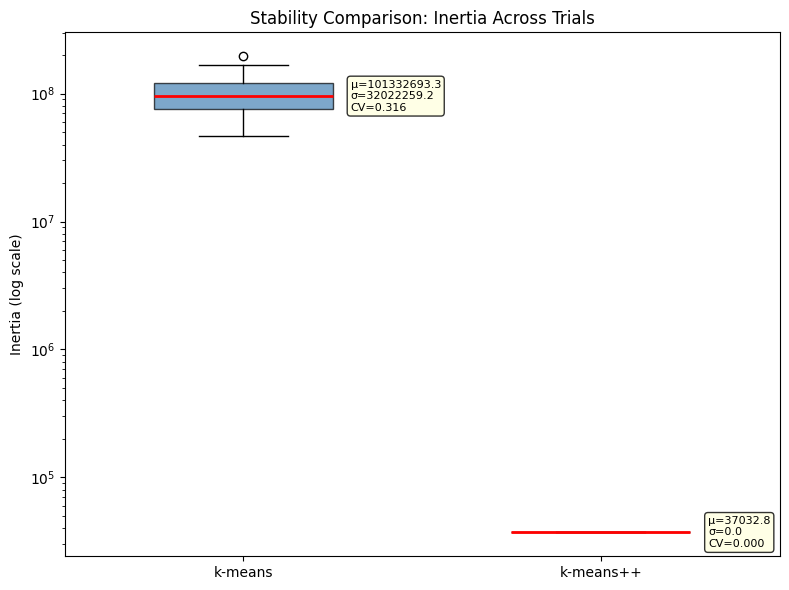

,k-means,k-means++
Mean Inertia,101332693.28,37032.77
Std Inertia,32022259.21,0.00
Min Inertia,46548358.39,37032.77
Max Inertia,196350906.87,37032.77
Median Inertia,95622855.95,37032.77
CV Inertia,0.32,0.00


Percentage improvement: 99.96%

Results for k = 50:


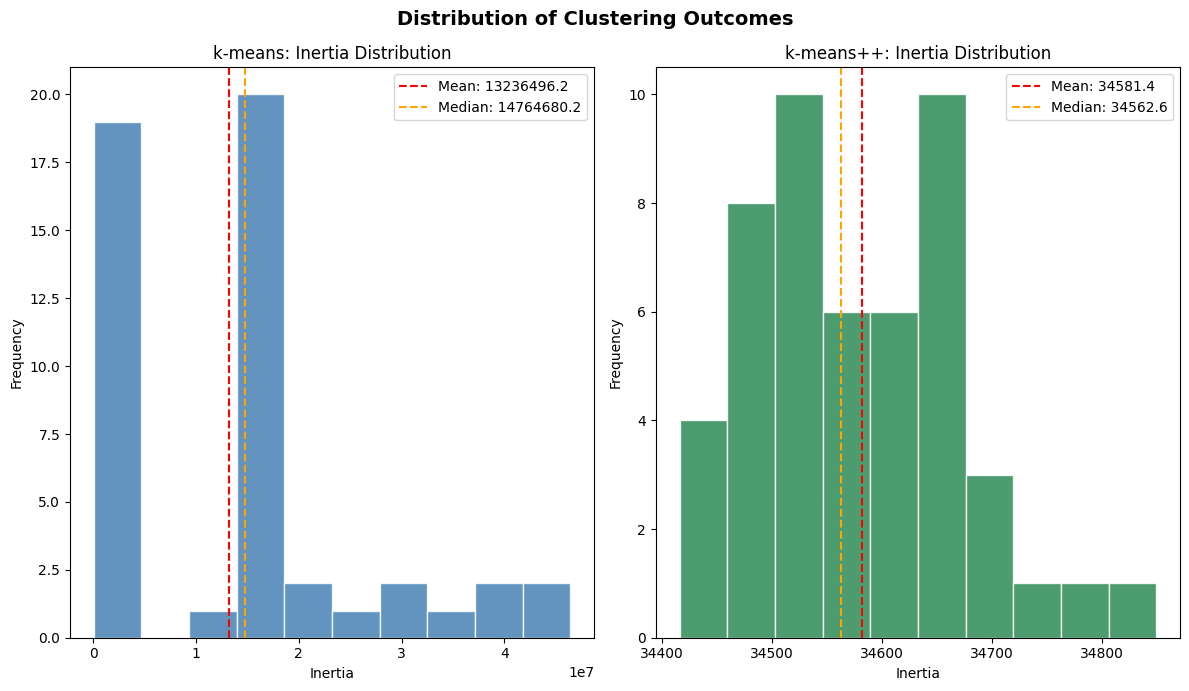

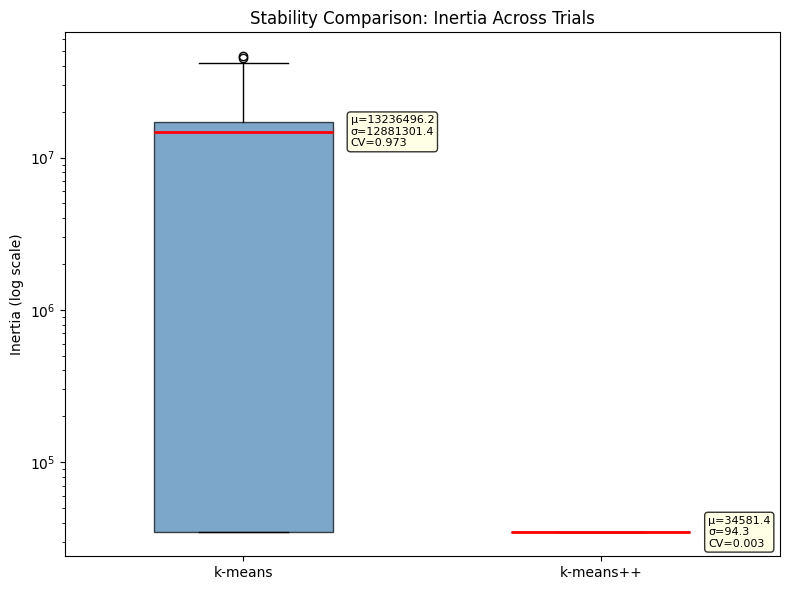

,k-means,k-means++
Mean Inertia,13236496.21,34581.35
Std Inertia,12881301.40,94.33
Min Inertia,34521.93,34416.23
Max Inertia,46426259.48,34849.01
Median Inertia,14764680.22,34562.55
CV Inertia,0.97,0.00


Percentage improvement: 99.74%



In [39]:
plt.close(widget_fig)
%matplotlib inline
# synthetic dataset
_, points = synthetic_dataset(25, 100, 15)

# I use the same values of k as the ones in the paper
for k in ks:
    print(f'Results for k = {k}:')
    run_trials_and_print_results(N_TRIALS, k, points, 'synth_25_100_15_500', save_tex=TEX)
    print()

#### Real world datasets

Results for k = 10:


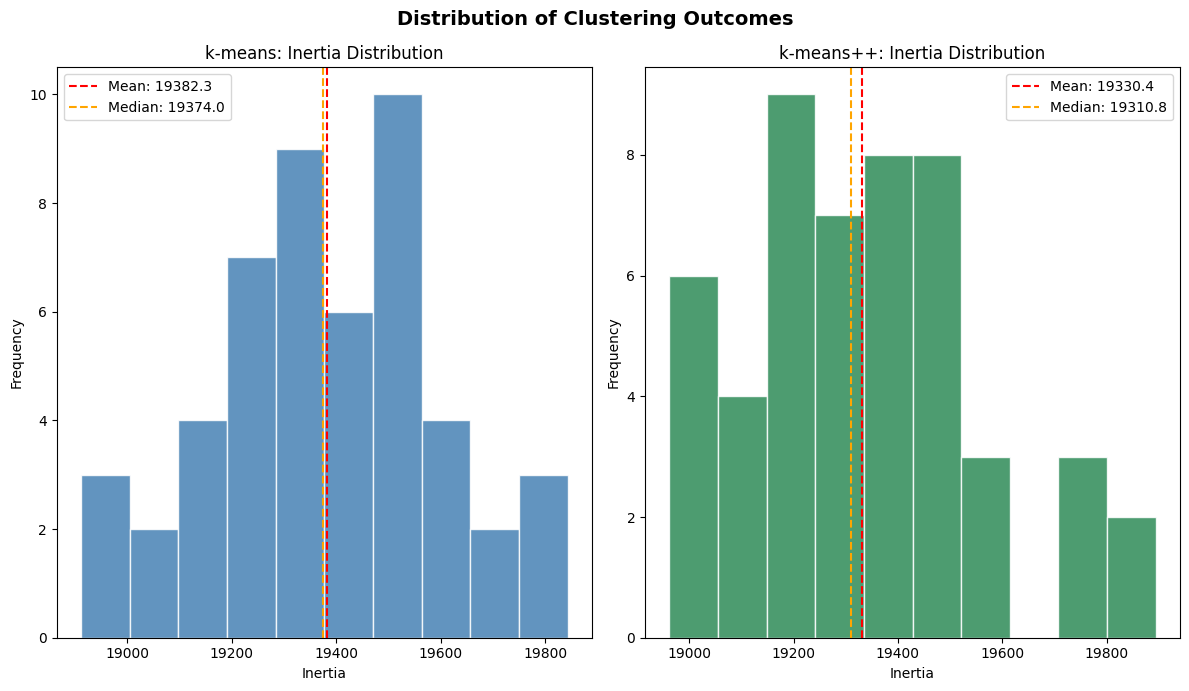

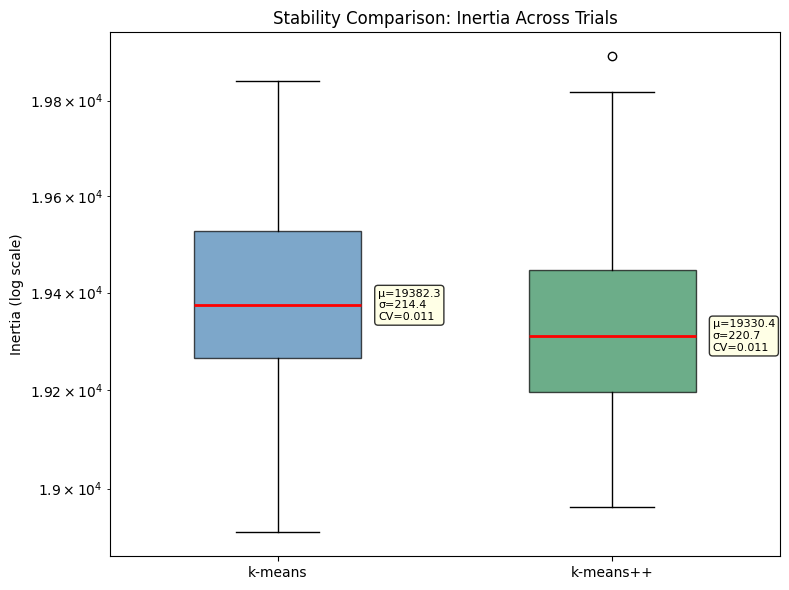

,k-means,k-means++
Mean Inertia,19382.33,19330.44
Std Inertia,214.35,220.74
Min Inertia,18911.71,18962.09
Max Inertia,19842.47,19893.97
Median Inertia,19374.04,19310.79
CV Inertia,0.01,0.01


Percentage improvement: 0.27%

Results for k = 25:


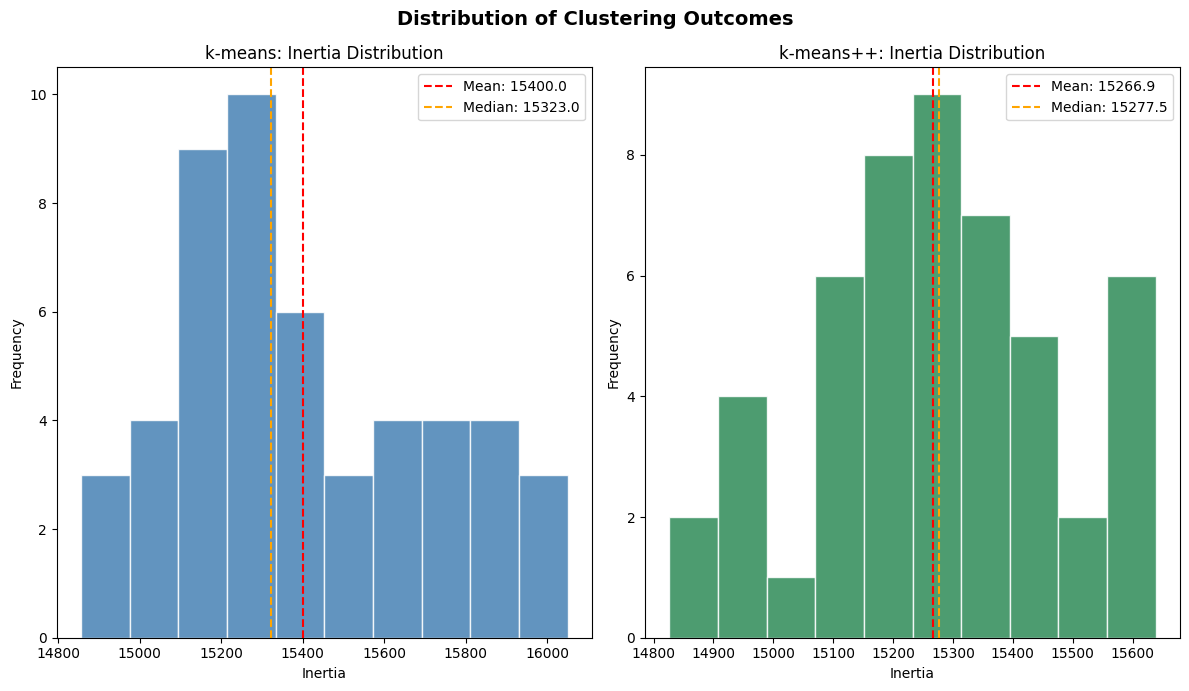

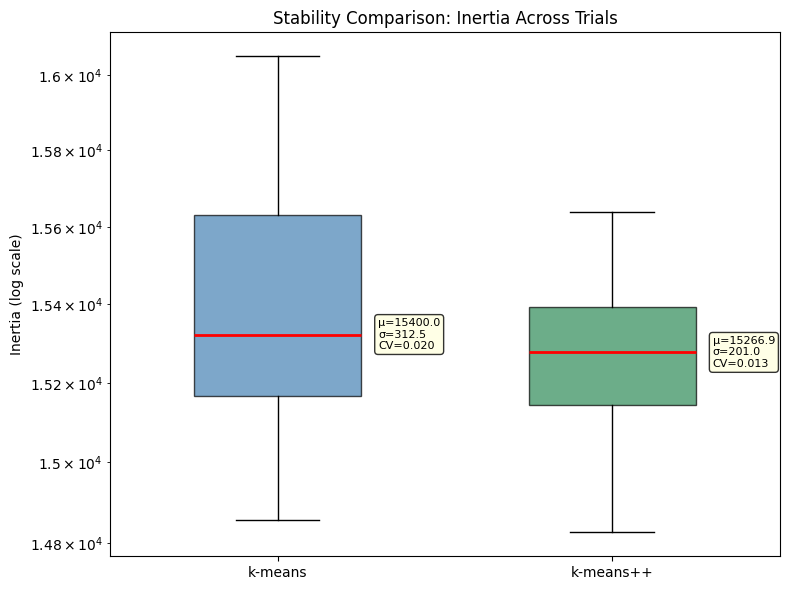

,k-means,k-means++
Mean Inertia,15400.03,15266.86
Std Inertia,312.52,201.03
Min Inertia,14856.91,14826.31
Max Inertia,16049.74,15638.60
Median Inertia,15322.95,15277.46
CV Inertia,0.02,0.01


Percentage improvement: 0.86%

Results for k = 50:


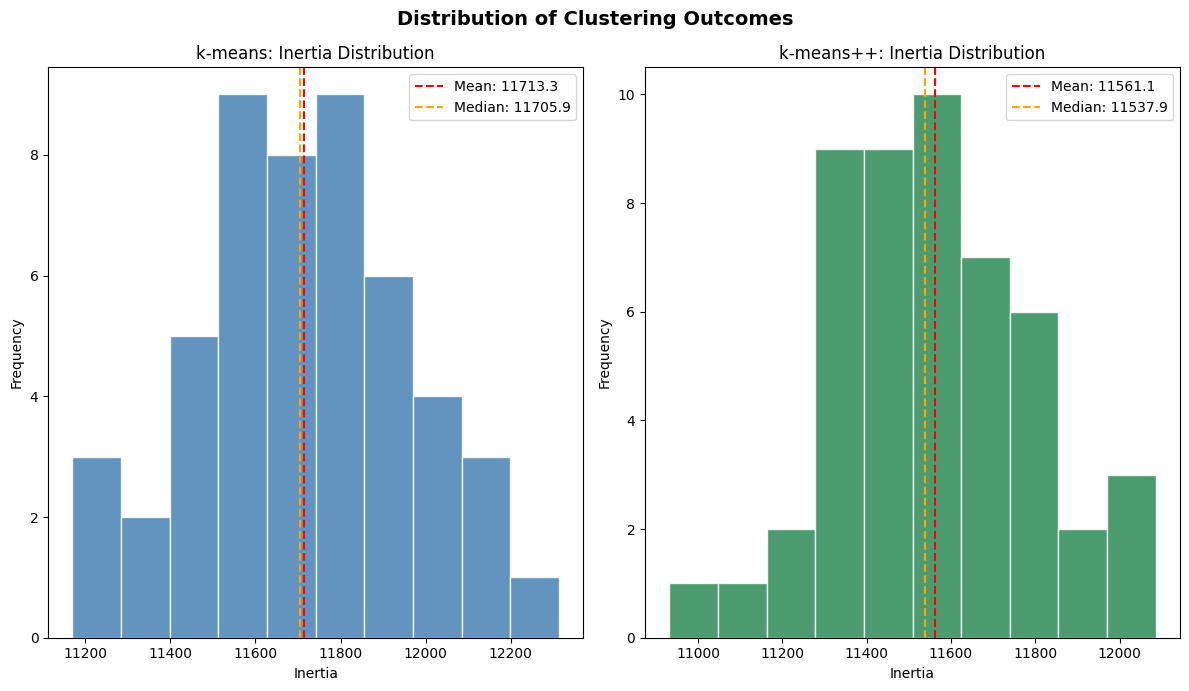

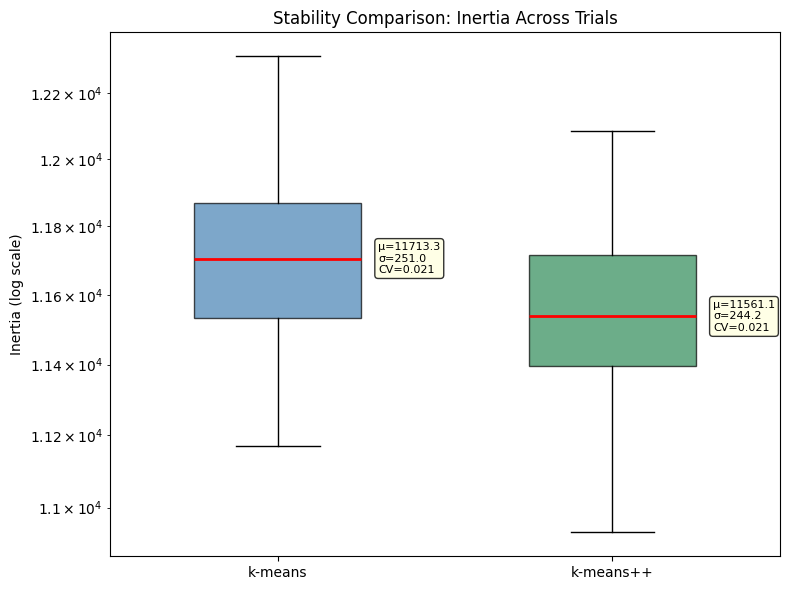

,k-means,k-means++
Mean Inertia,11713.30,11561.08
Std Inertia,250.99,244.20
Min Inertia,11170.38,10931.99
Max Inertia,12312.71,12085.64
Median Inertia,11705.88,11537.91
CV Inertia,0.02,0.02


Percentage improvement: 1.30%



In [ ]:
# olivetti faces
from sklearn.datasets import fetch_olivetti_faces

points, _ = fetch_olivetti_faces(return_X_y=True)
for k in [10, 25, 50]:
    print(f'Results for k = {k}:')
    run_trials_and_print_results(N_TRIALS, k, points, 'olivetti_faces', save_tex=TEX)
    print()

## Extensions
The cells below implements the two extensions of the project:
- High Dimensionality dataset
- Overlapping cluster

Results for k = 10:


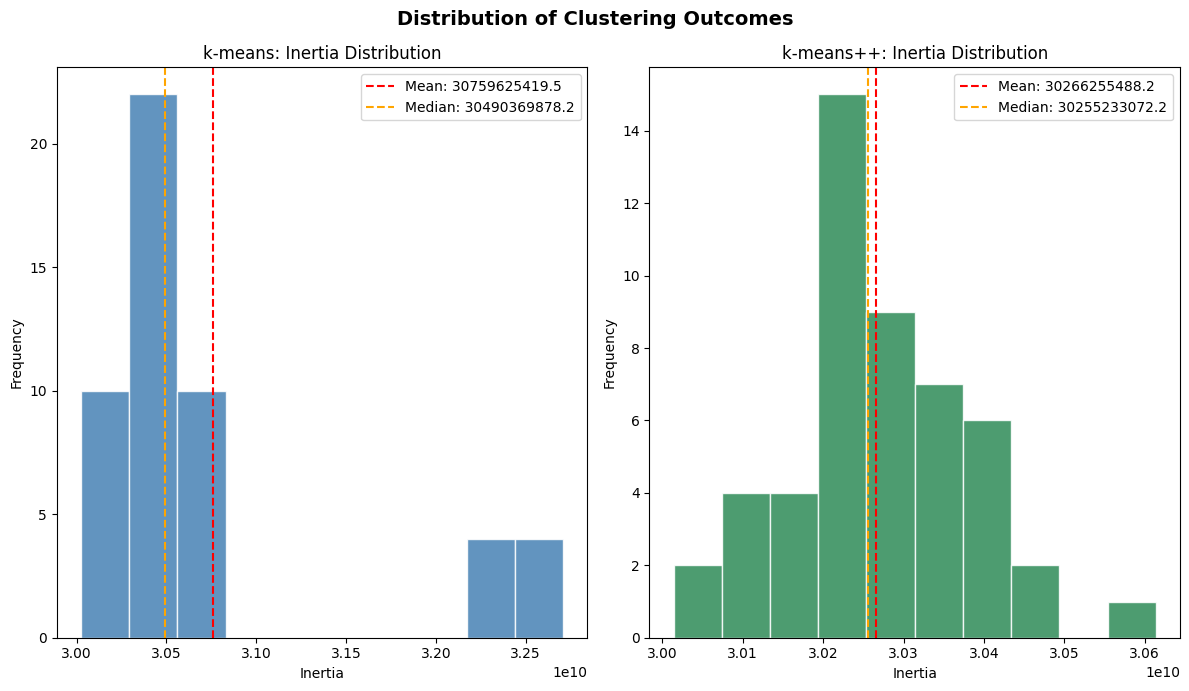

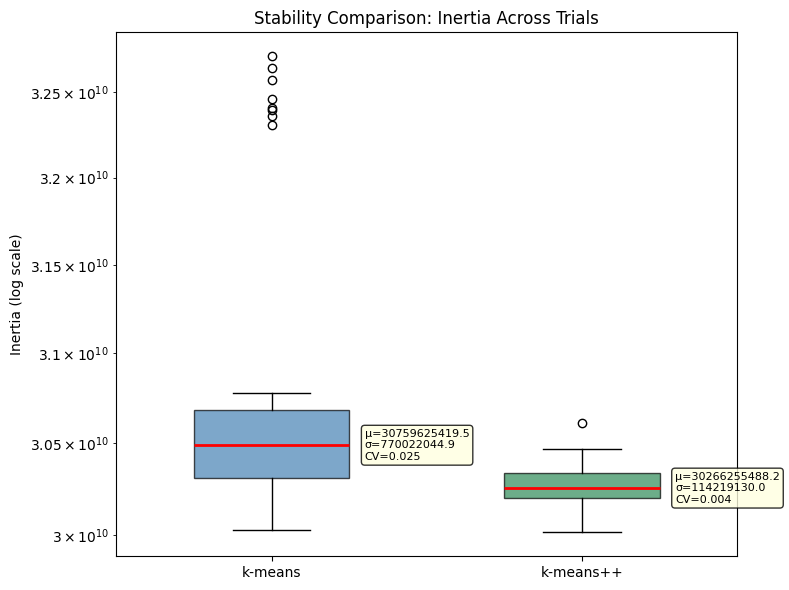

,k-means,k-means++
Mean Inertia,30759625419.52,30266255488.24
Std Inertia,770022044.94,114219129.98
Min Inertia,30024490522.05,30013835236.53
Max Inertia,32709669266.99,30613841962.18
Median Inertia,30490369878.22,30255233072.19
CV Inertia,0.03,0.00


Percentage improvement: 1.60%

Results for k = 20:


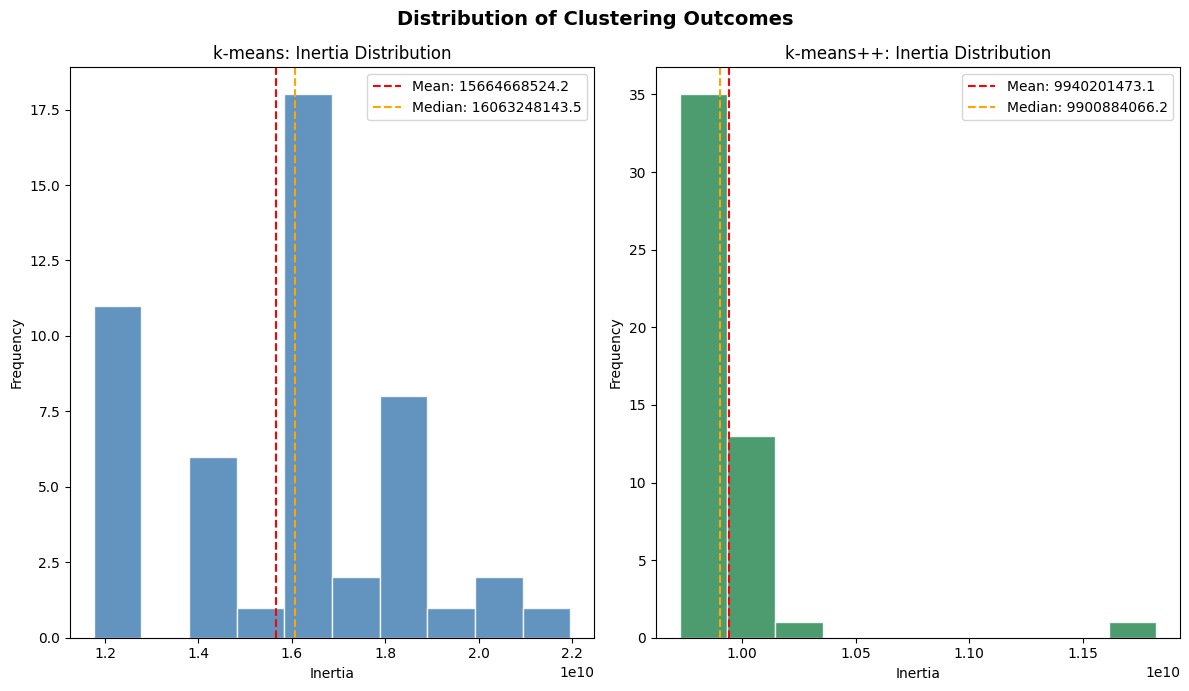

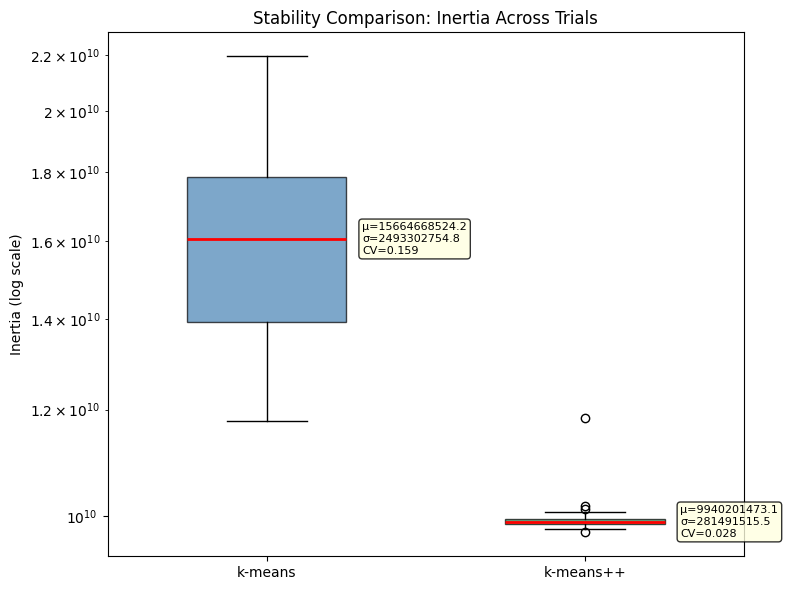

,k-means,k-means++
Mean Inertia,15664668524.20,9940201473.15
Std Inertia,2493302754.80,281491515.54
Min Inertia,11759538918.44,9724431862.44
Max Inertia,21959707595.81,11824487704.00
Median Inertia,16063248143.45,9900884066.18
CV Inertia,0.16,0.03


Percentage improvement: 36.54%

Results for k = 25:


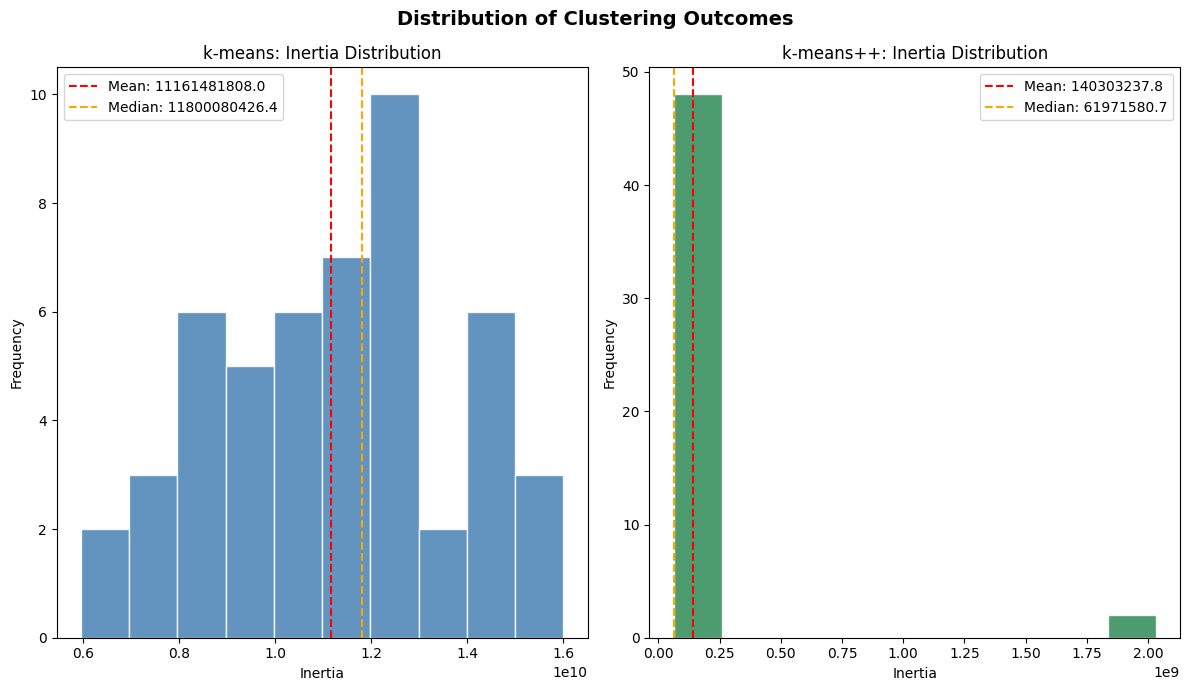

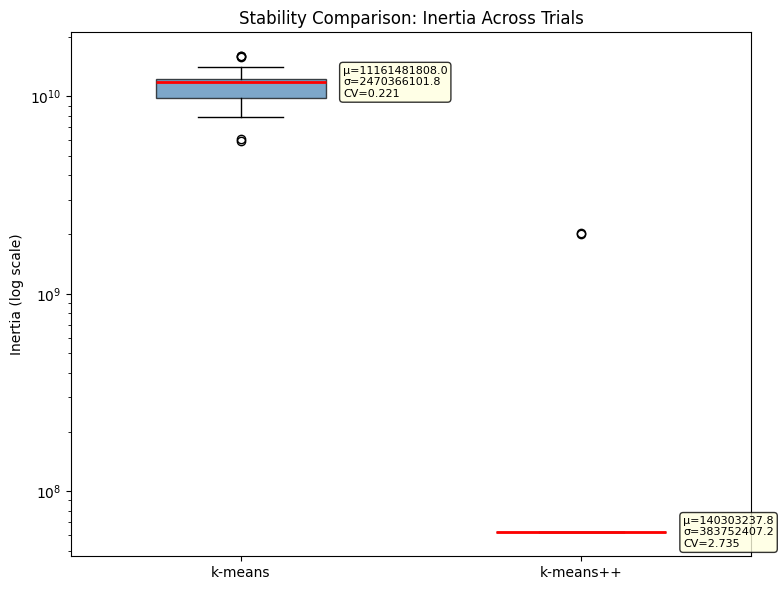

,k-means,k-means++
Mean Inertia,11161481808.01,140303237.75
Std Inertia,2470366101.85,383752407.19
Min Inertia,5962823850.35,61971580.67
Max Inertia,16001282038.16,2032037968.36
Median Inertia,11800080426.43,61971580.67
CV Inertia,0.22,2.74


Percentage improvement: 98.74%

Results for k = 40:


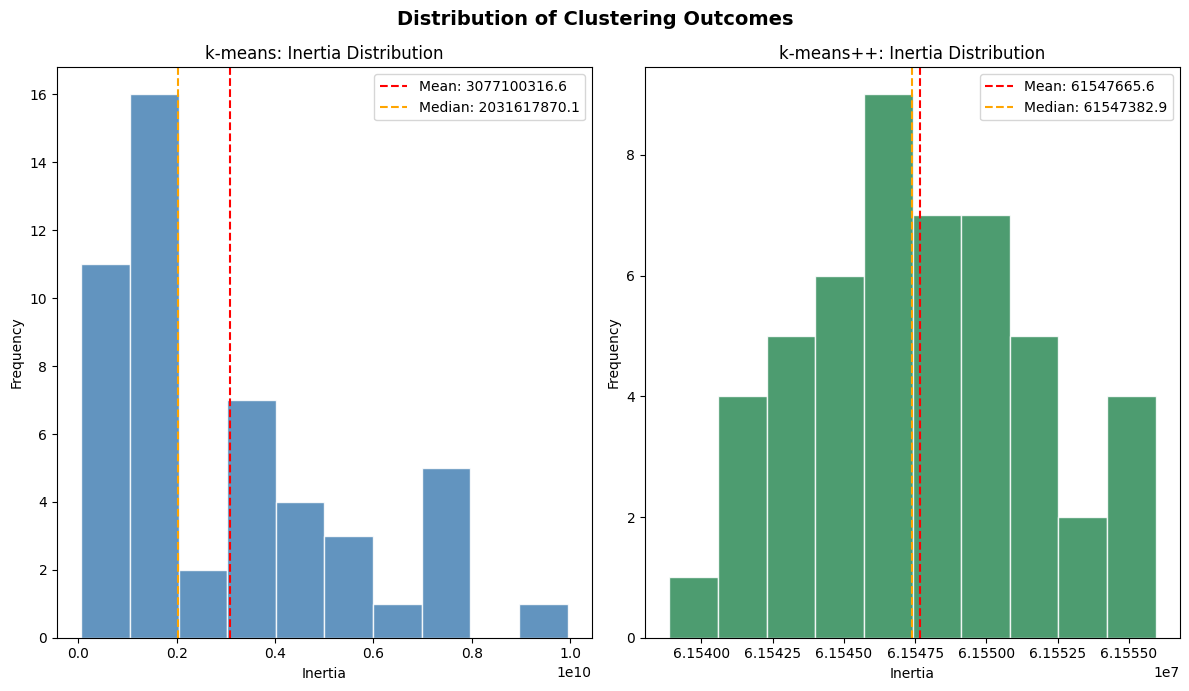

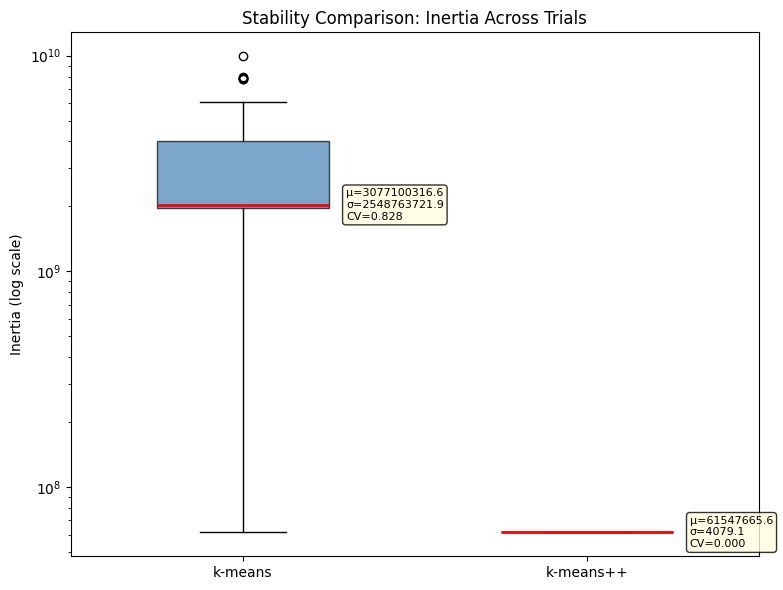

,k-means,k-means++
Mean Inertia,3077100316.63,61547665.63
Std Inertia,2548763721.90,4079.11
Min Inertia,61542211.94,61538881.52
Max Inertia,9945797850.13,61555939.38
Median Inertia,2031617870.07,61547382.89
CV Inertia,0.83,0.00


Percentage improvement: 98.00%

Results for k = 50:


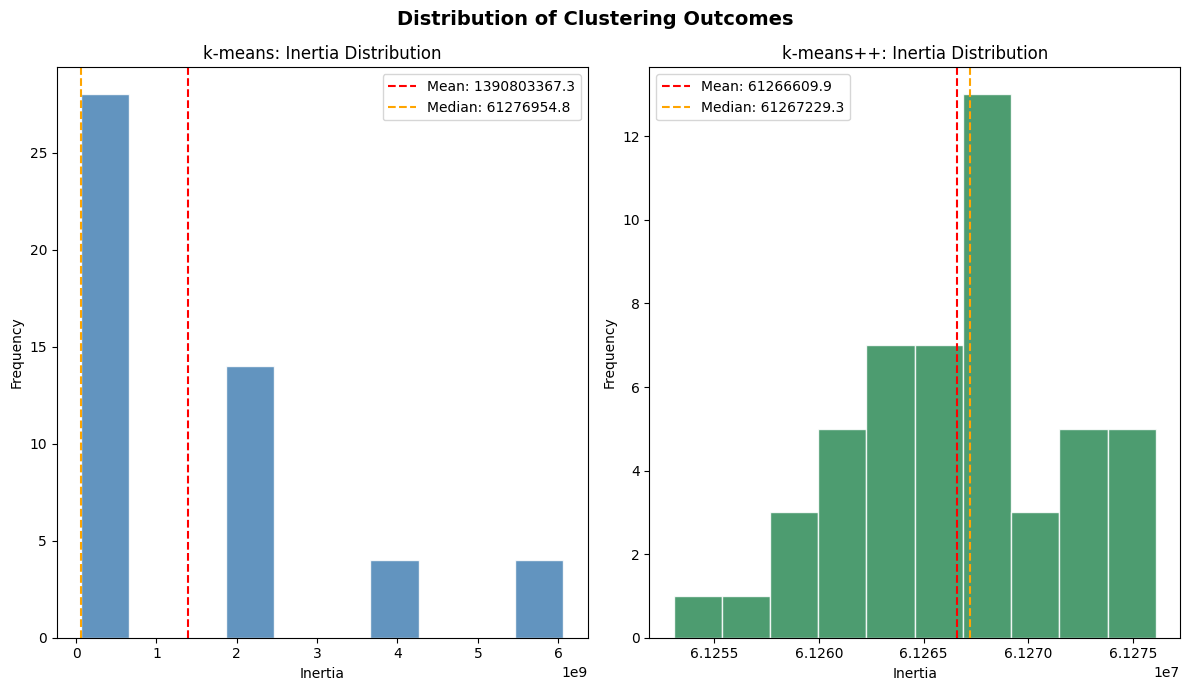

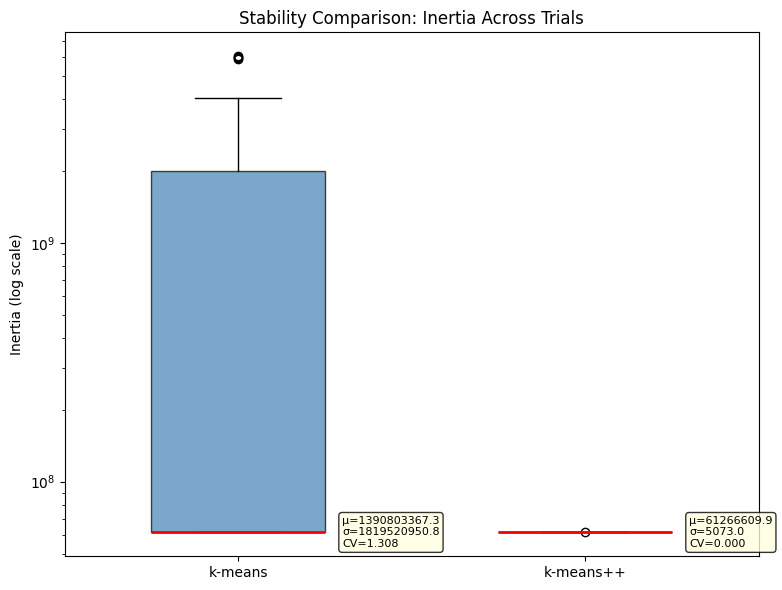

,k-means,k-means++
Mean Inertia,1390803367.28,61266609.90
Std Inertia,1819520950.78,5072.97
Min Inertia,61257625.96,61253052.58
Max Inertia,6064487436.88,61276104.01
Median Inertia,61276954.80,61267229.31
CV Inertia,1.31,0.00


Percentage improvement: 95.59%



In [41]:
# High Dimensionality
_, points = synthetic_dataset(25, 100, 1000, sigma=5, hypercube_side=500)

for k in [10, 20, 25, 40, 50]:
    print(f'Results for k = {k}:')
    run_trials_and_print_results(N_TRIALS, k, points, 'high_dim', save_tex=TEX)
    print()

Results for k = 10:


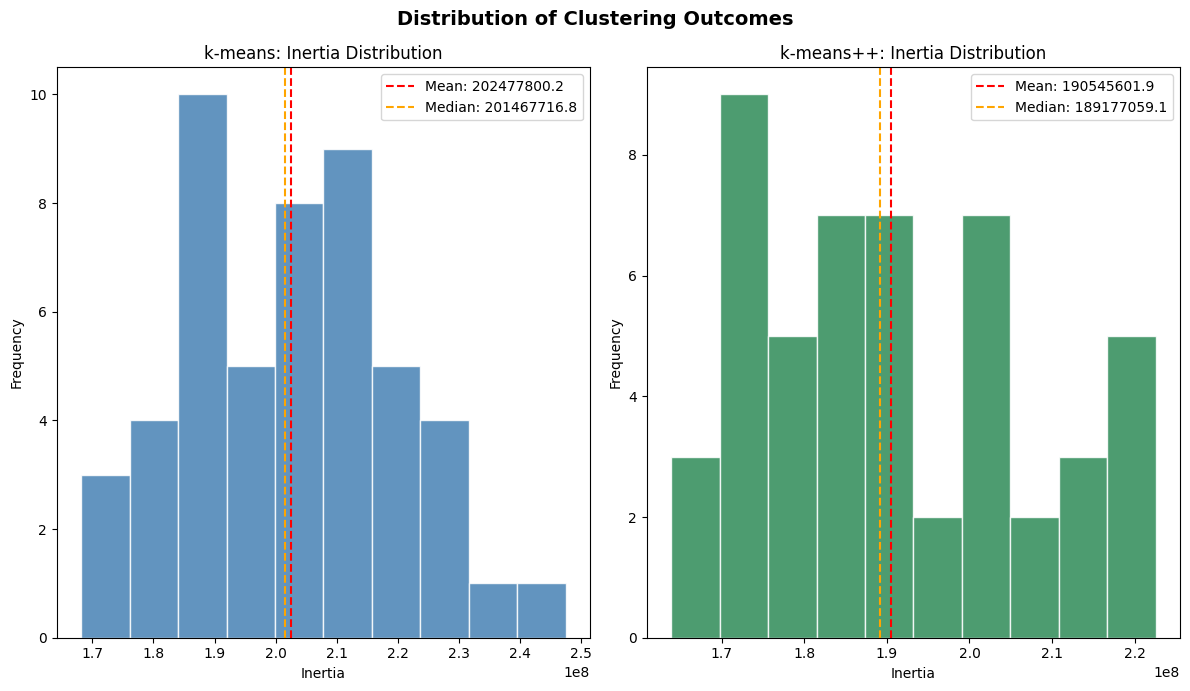

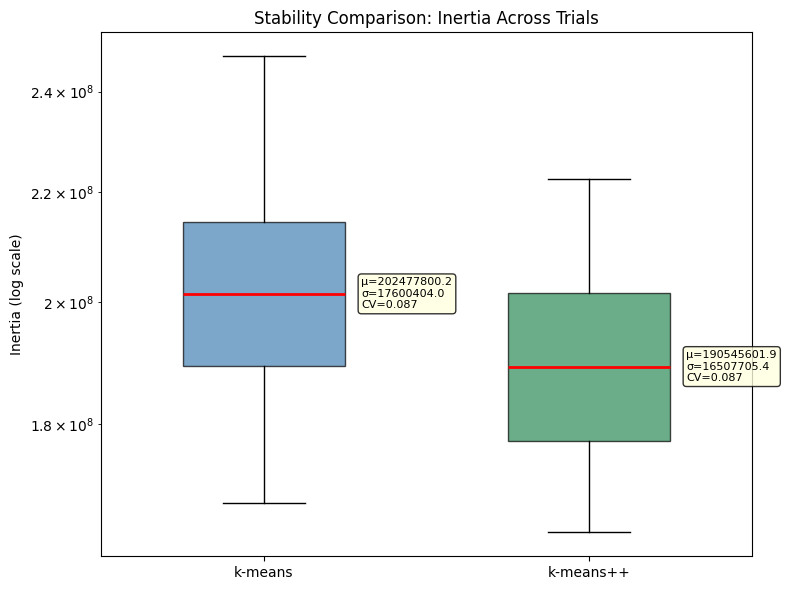

,k-means,k-means++
Mean Inertia,202477800.17,190545601.90
Std Inertia,17600403.98,16507705.45
Min Inertia,168156616.85,163878406.68
Max Inertia,247488632.03,222560736.24
Median Inertia,201467716.78,189177059.10
CV Inertia,0.09,0.09


Percentage improvement: 5.89%

Results for k = 20:


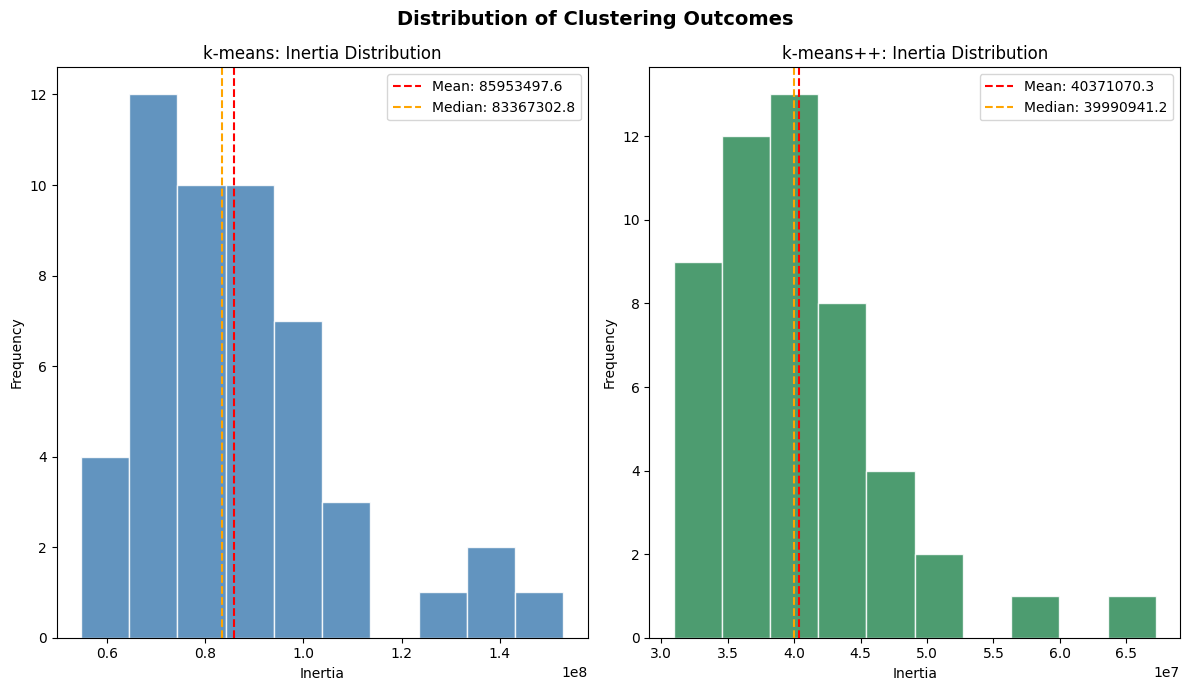

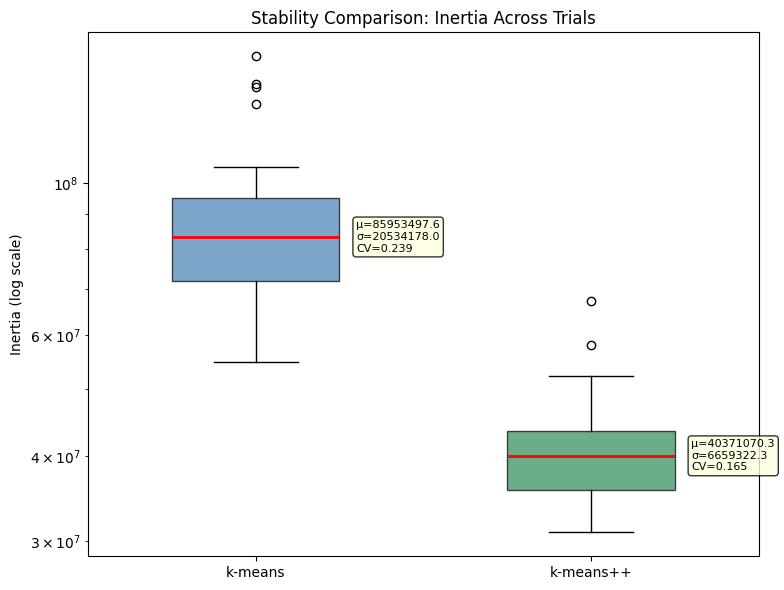

,k-means,k-means++
Mean Inertia,85953497.56,40371070.29
Std Inertia,20534177.95,6659322.27
Min Inertia,54710211.41,30918475.34
Max Inertia,152968875.98,67232777.06
Median Inertia,83367302.78,39990941.21
CV Inertia,0.24,0.16


Percentage improvement: 53.03%

Results for k = 25:


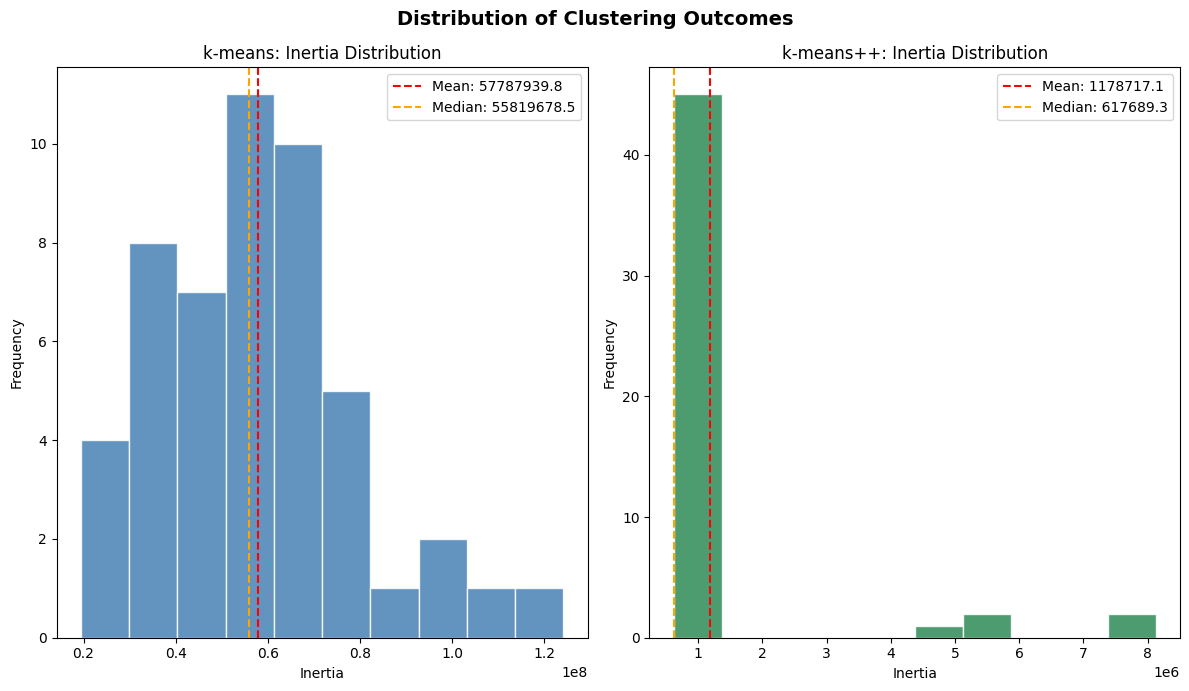

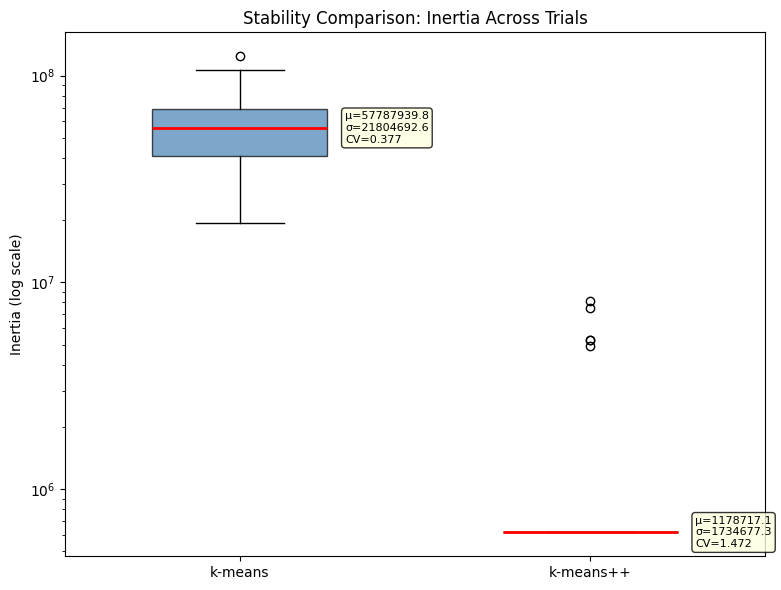

,k-means,k-means++
Mean Inertia,57787939.76,1178717.10
Std Inertia,21804692.58,1734677.34
Min Inertia,19451722.09,617689.27
Max Inertia,124139342.56,8127323.79
Median Inertia,55819678.50,617689.27
CV Inertia,0.38,1.47


Percentage improvement: 97.96%

Results for k = 40:


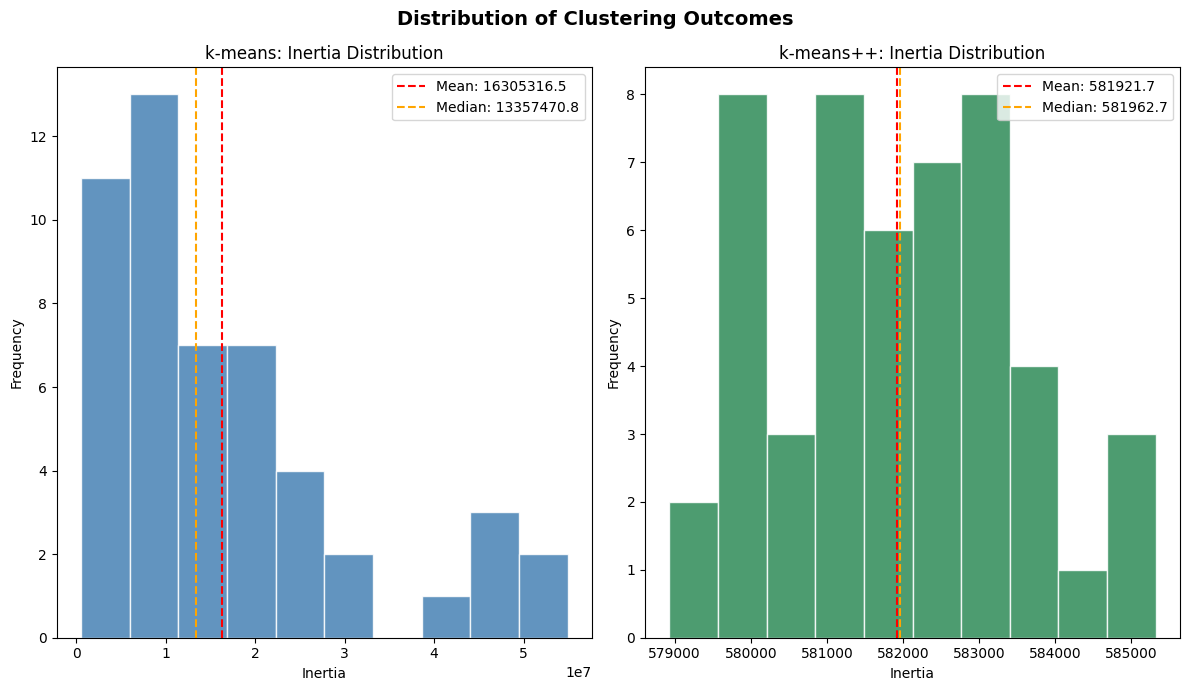

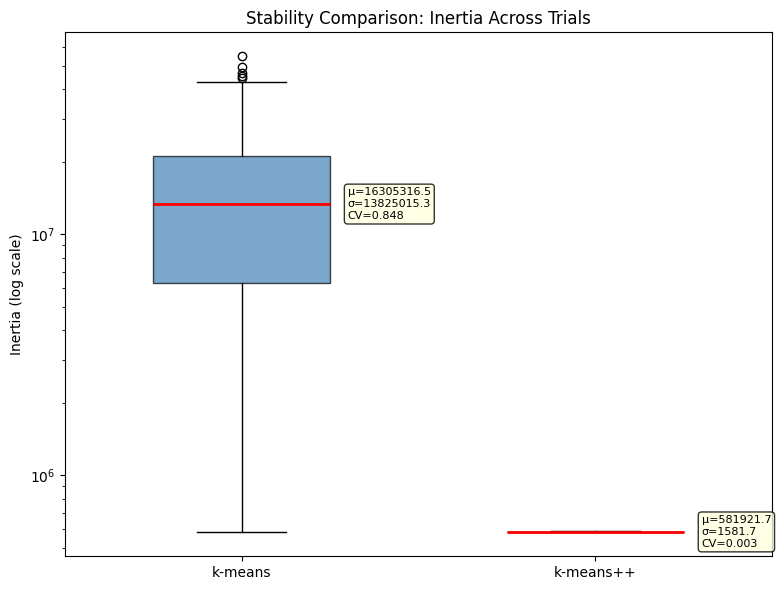

,k-means,k-means++
Mean Inertia,16305316.50,581921.70
Std Inertia,13825015.29,1581.68
Min Inertia,581398.01,578929.47
Max Inertia,54915287.96,585321.63
Median Inertia,13357470.76,581962.74
CV Inertia,0.85,0.00


Percentage improvement: 96.43%

Results for k = 50:


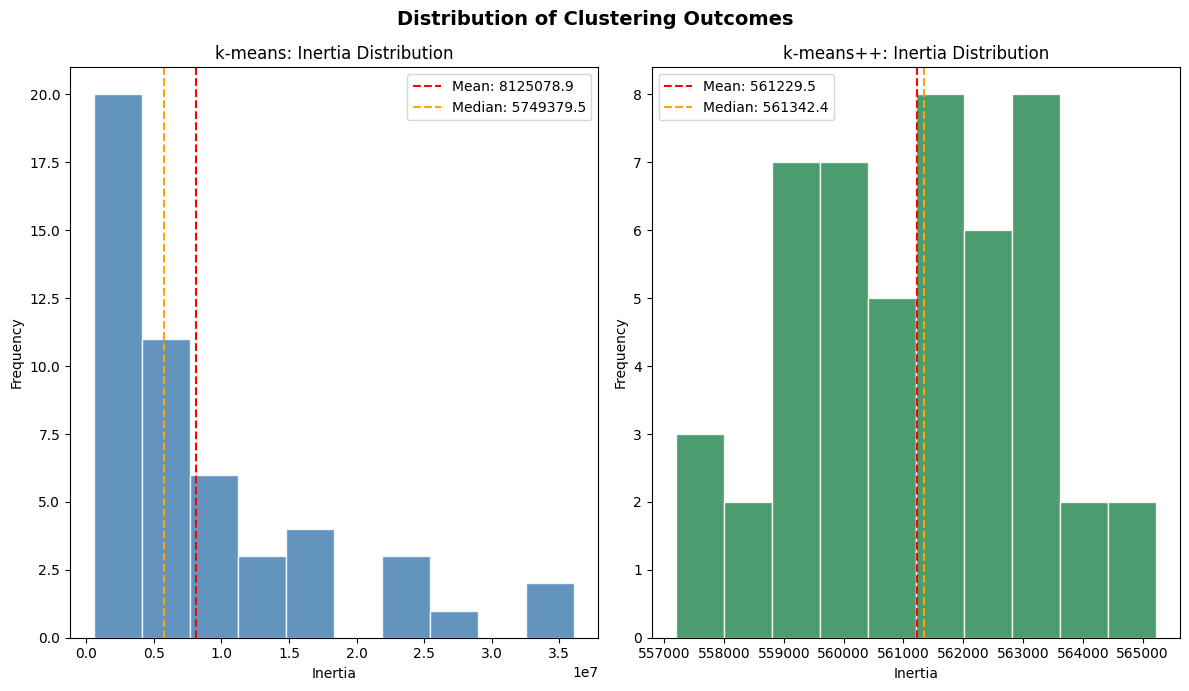

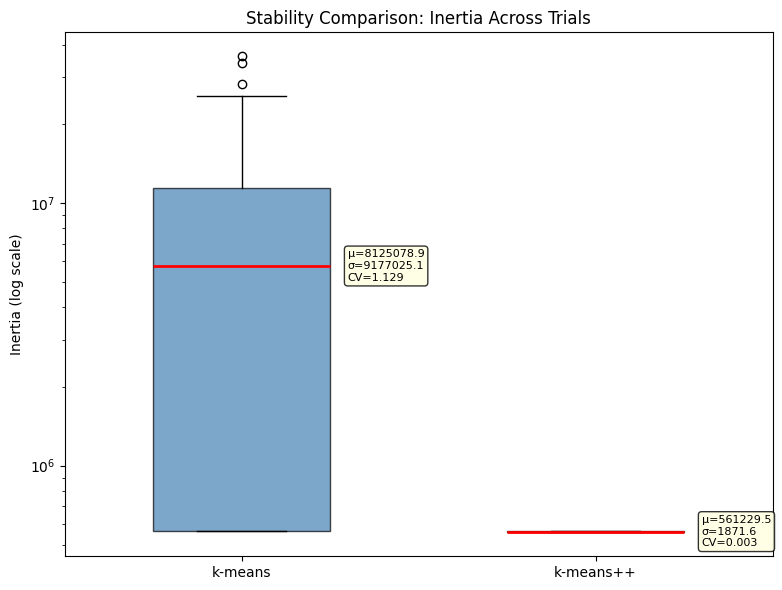

,k-means,k-means++
Mean Inertia,8125078.95,561229.51
Std Inertia,9177025.10,1871.59
Min Inertia,561959.68,557190.97
Max Inertia,36137177.87,565221.30
Median Inertia,5749379.55,561342.37
CV Inertia,1.13,0.00


Percentage improvement: 93.09%



In [42]:
# low Dimensionality
_, points = synthetic_dataset(25, 100, 10, sigma=5, hypercube_side=500)

for k in [10, 20, 25, 40, 50]:
    print(f'Results for k = {k}:')
    run_trials_and_print_results(N_TRIALS, k, points, 'high_dim', save_tex=TEX)
    print()

Results for k = 10:


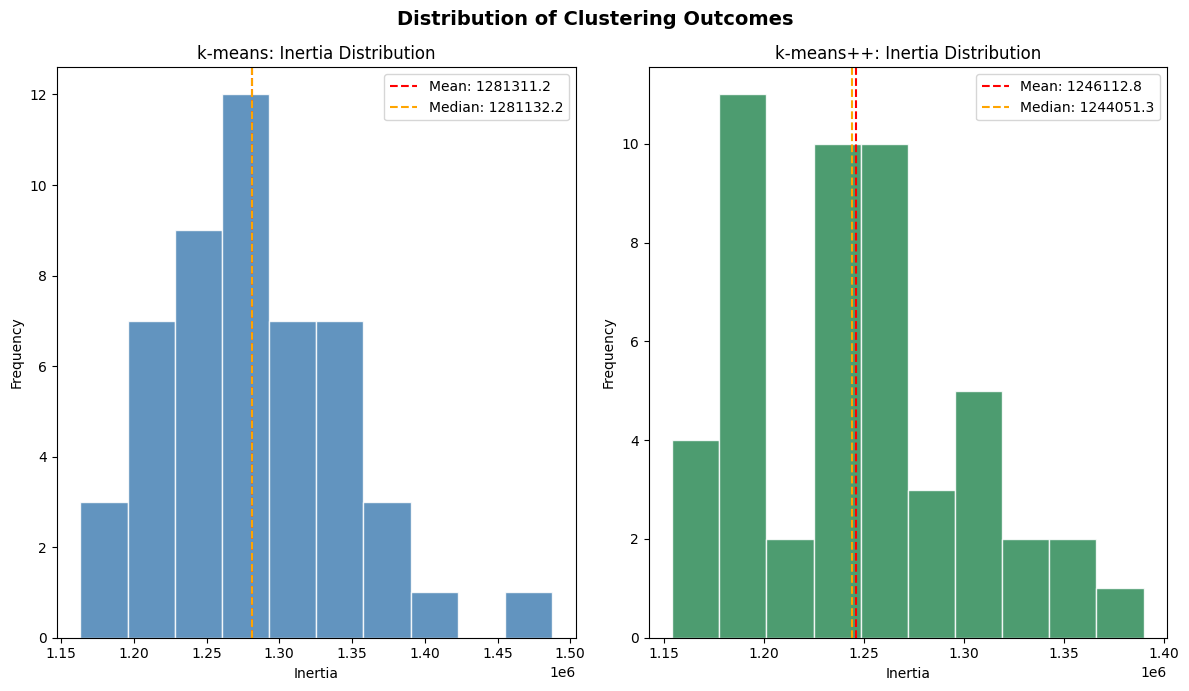

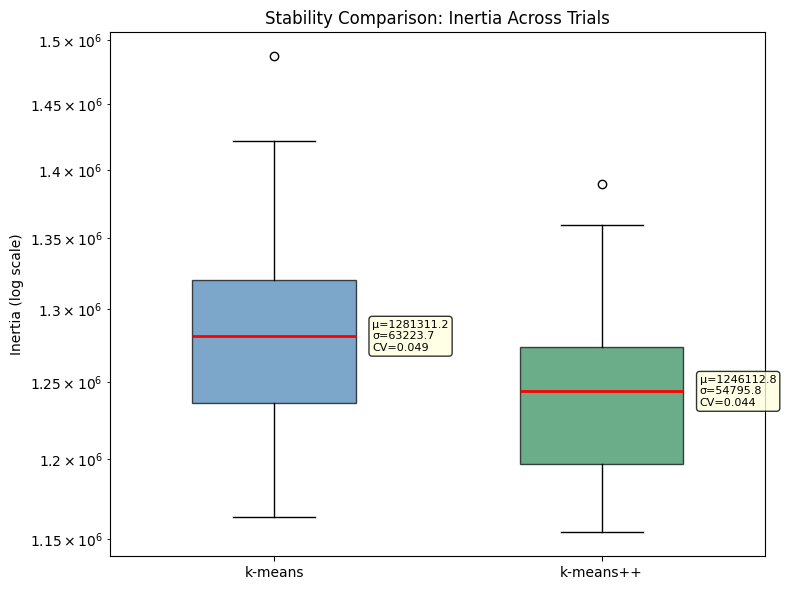

,k-means,k-means++
Mean Inertia,1281311.20,1246112.84
Std Inertia,63223.74,54795.76
Min Inertia,1163353.45,1153904.80
Max Inertia,1487410.96,1389778.99
Median Inertia,1281132.20,1244051.26
CV Inertia,0.05,0.04


Percentage improvement: 2.75%

Results for k = 20:


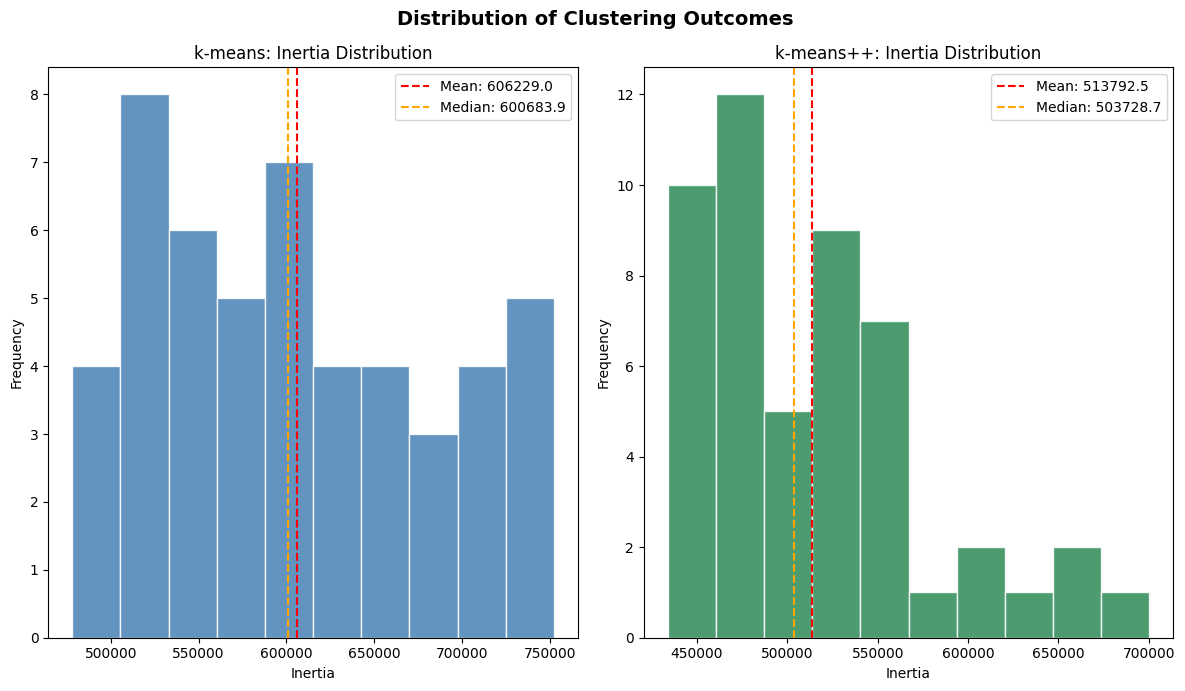

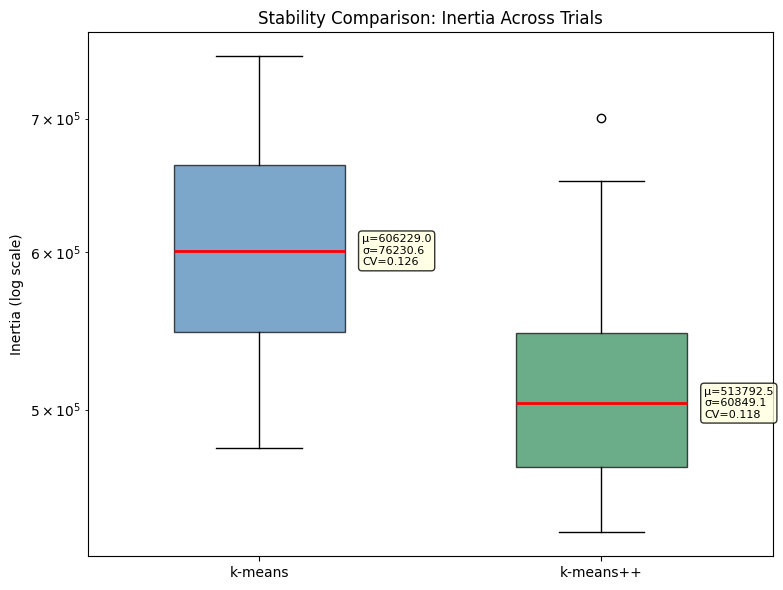

,k-means,k-means++
Mean Inertia,606229.01,513792.46
Std Inertia,76230.58,60849.14
Min Inertia,478043.78,433758.56
Max Inertia,752392.04,700332.85
Median Inertia,600683.94,503728.72
CV Inertia,0.13,0.12


Percentage improvement: 15.25%

Results for k = 25:


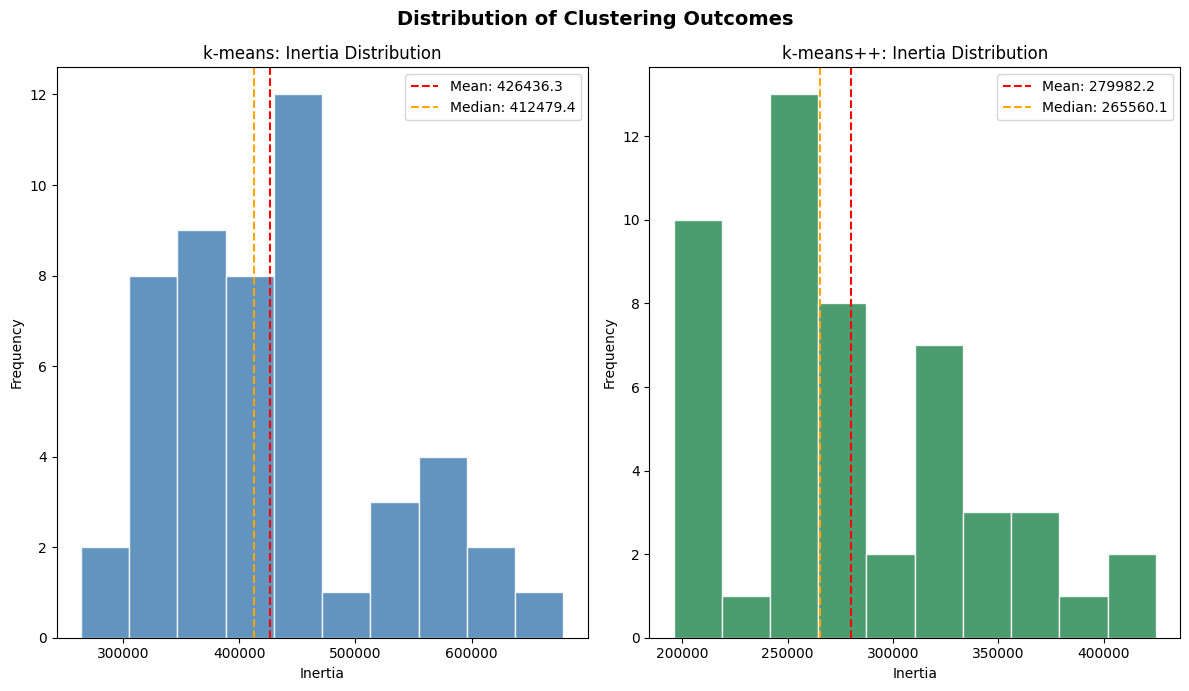

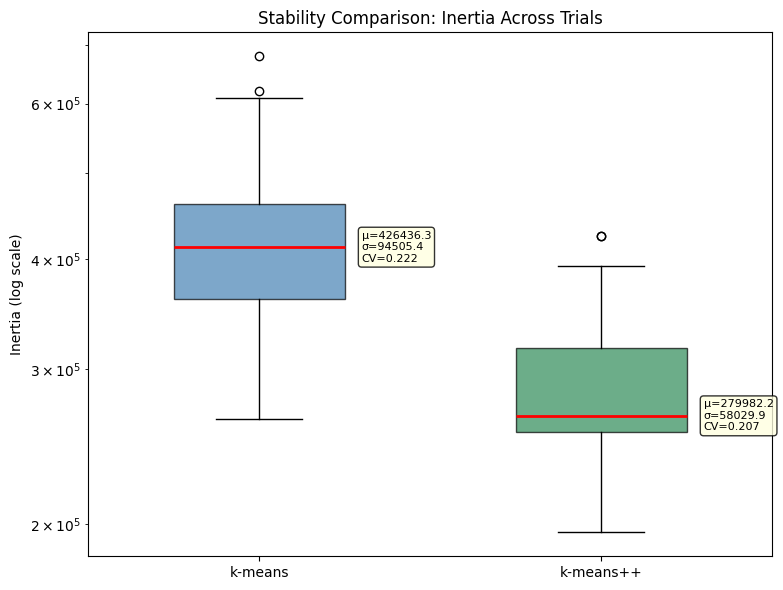

,k-means,k-means++
Mean Inertia,426436.28,279982.18
Std Inertia,94505.44,58029.87
Min Inertia,263449.72,195853.76
Max Inertia,679186.84,424743.20
Median Inertia,412479.38,265560.11
CV Inertia,0.22,0.21


Percentage improvement: 34.34%

Results for k = 40:


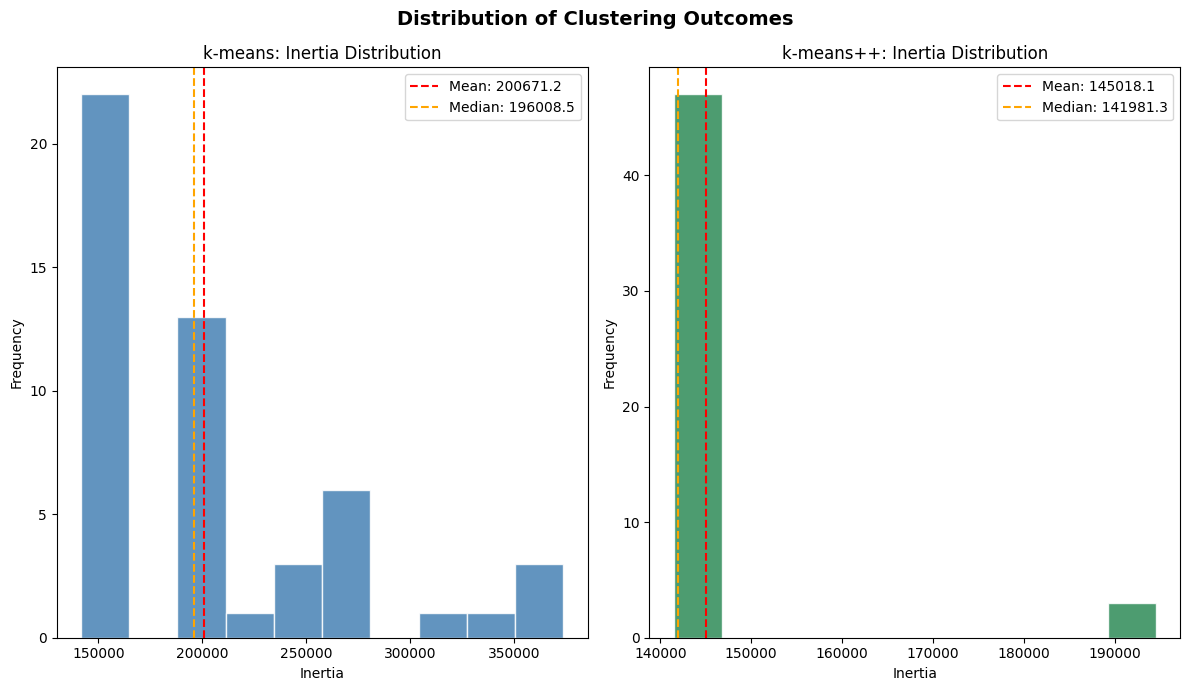

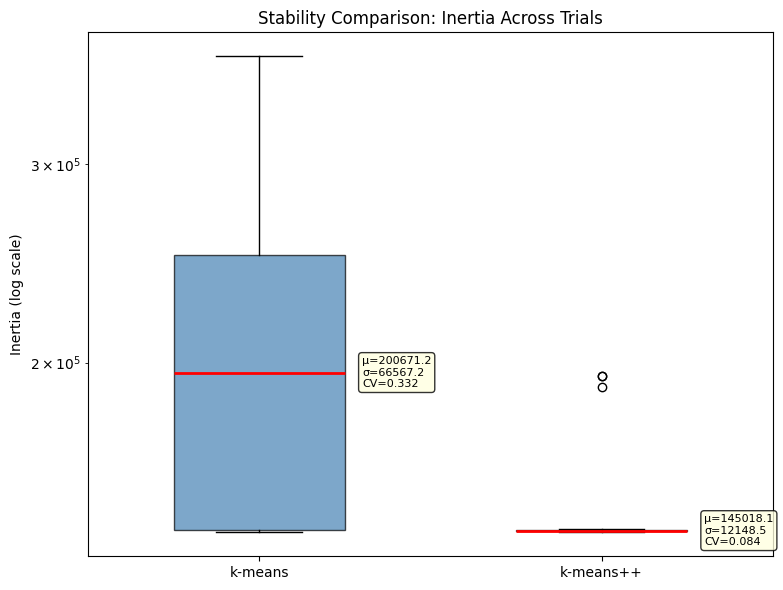

,k-means,k-means++
Mean Inertia,200671.18,145018.09
Std Inertia,66567.19,12148.47
Min Inertia,141594.12,141452.35
Max Inertia,373775.08,194507.40
Median Inertia,196008.54,141981.27
CV Inertia,0.33,0.08


Percentage improvement: 27.73%

Results for k = 50:


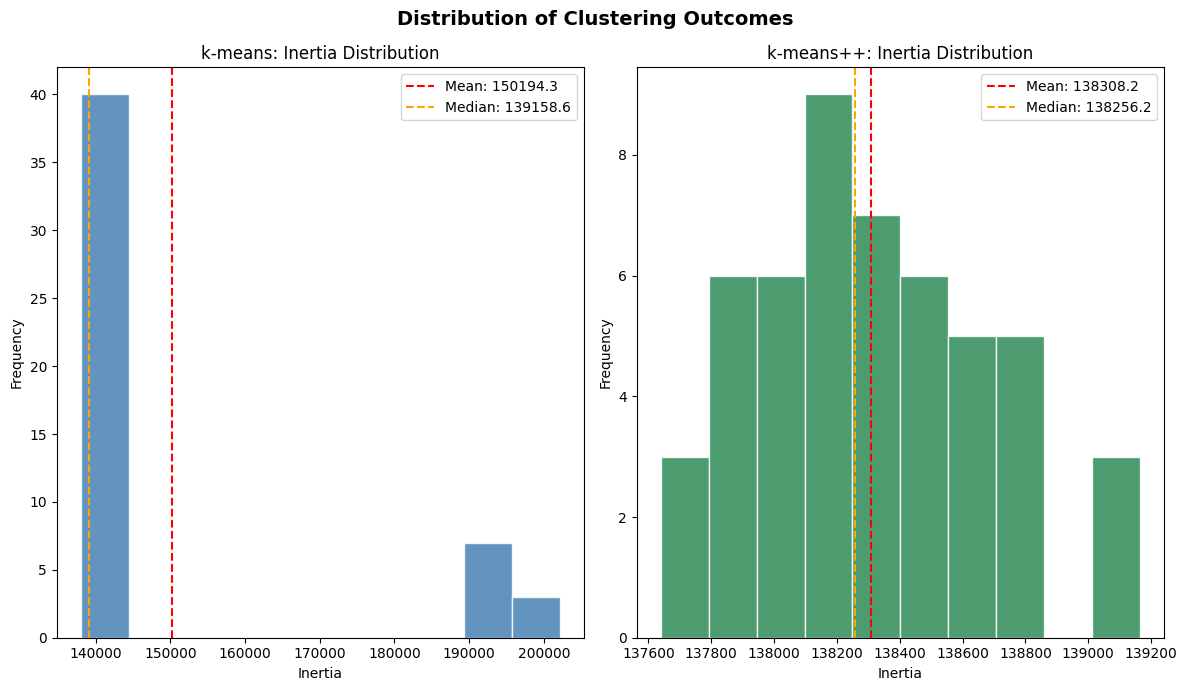

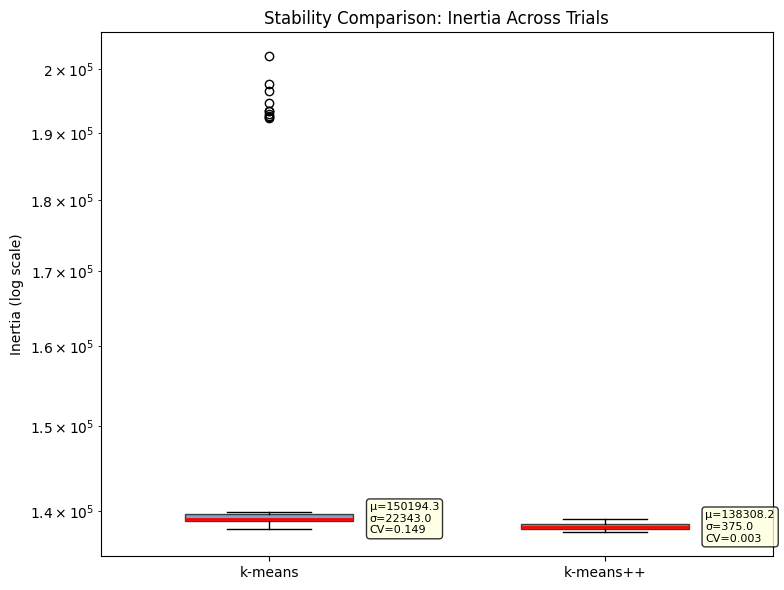

,k-means,k-means++
Mean Inertia,150194.26,138308.20
Std Inertia,22343.01,374.97
Min Inertia,138010.63,137639.81
Max Inertia,202129.84,139163.91
Median Inertia,139158.60,138256.19
CV Inertia,0.15,0.00


Percentage improvement: 7.91%



In [43]:
# Overlapping Clusters
_, points = synthetic_dataset(25, 100, 15, sigma=2, hypercube_side=30, seed=42)

for k in [10, 20, 25, 40, 50]:
    print(f'Results for k = {k}:')
    run_trials_and_print_results(N_TRIALS, k, points, 'overlapping', save_tex=TEX)
    print()